<div style="display: flex; background-color: RGB(255,114,0);">
  <h1 style="margin: auto; padding: 30px; color: white;">ANALYSE DES VENTES DE LA LIBRAIRIE LAPAGE</h1>
</di>


# OBJECTIF DE CE NOTEBOOK

Ce notebook a pour objectif d'analyser les ventes en ligne de la librairie **Lapage**, anciennement librairie physique.  
L'étude s'appuie sur les données de transactions, produits et clients collectées depuis le lancement de la boutique en ligne.

Dans une **première partie**, nous allons explorer les indicateurs clés suivants :
- L’évolution du **chiffre d’affaires** dans le temps (avec moyenne mobile),
- Le **chiffre d’affaires par catégorie de livres**,
- Le **nombre de clients actifs** par mois,
- Le **nombre de transactions** et de **produits vendus**,
- L’analyse des **références les plus et les moins vendues**,
- La **répartition du chiffre d'affaires BtoB**,
- Et des visualisations supplémentaires utiles à la prise de décision.

---

Dans une **seconde partie**, nous approfondirons l’analyse des **comportements clients**.  
Nous chercherons à identifier d’éventuelles corrélations entre les caractéristiques des clients et leurs habitudes d’achat, à travers cinq axes principaux :
- Le lien entre le **genre du client** et les **catégories de livres achetées**,
- Le lien entre l’**âge** et le **montant total des achats**,
- Le lien entre l’**âge** et la **fréquence d’achat**,
- Le lien entre l’**âge** et le **prix moyen**,
- Et enfin, le lien entre l’**âge** et les **catégories de livres préférées**.

Ces analyses statistiques seront accompagnées de visualisations et de tests appropriés.


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 1 – ANALYSE DES VENTES</h2>
</di
>


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">1.1 – Importation des librairies</h3>
</di>


In [5]:
#Importation de la librairie Pandas (pour manipuler les DataFrames)
import pandas as pd

# Importation de la librairie Numpy (pour effectuer certaines transformations numériques)
import numpy as np

#Importation de la librairie plotly express (pour les visualisations interactives comme la courbe de Lorenz)
import plotly.express as px

#Importation de la librairie Matplotlib (pour les graphiques statiques classiques : histogrammes, barplots, heatmaps)
import matplotlib.pyplot as plt

#Importation de la librairie Seaborn  (pour les graphiques statiques classiques : histogrammes, barplots, heatmaps)
import seaborn as sns

In [6]:
# Paramètres d'affichage
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [8]:
#Importation du fichier customers.csv
df_customers = pd.read_csv("customers.csv", sep=";")

#Importation du fichier products.csv
df_products = pd.read_csv("products.csv", sep=";")

#importation du fichier Transactions.csv
df_transactions = pd.read_csv("Transactions.csv", sep=";")

C:\Users\laure\AppData\Local\Temp\ipykernel_19988\2731567687.py:8: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("Transactions.csv", sep=";")


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.3 - Analyse exploratoire du fichier products.csv</h3>
</div>



Le fichier `products.csv` contient des informations sur l'ensemble des produits référencés par la librairie.  
Chaque ligne correspond à un produit, avec son identifiant, son prix et la catégorie associée.

Nous allons ici :
- vérifier la structure du fichier,
- détecter les valeurs manquantes ou doublons,
- analyser la distribution des prix,
- observer la répartition des produits par catégorie.

In [11]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_products.shape[0]))
print("\nLe tableau comporte {} colonne(s)".format(df_products.shape[1]))

Le tableau comporte 3286 observation(s) ou article(s)

Le tableau comporte 3 colonne(s)


In [12]:
# Affichage des premières lignes du dataset products.csv

print("Les 5 premières lignes de la table PRODUCTS se présentent ainsi :\n")
display(df_products.head())

Les 5 premières lignes de la table PRODUCTS se présentent ainsi :



,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [13]:
# Informations générales sur le fichier products.csv

print("\nInformations sur la table PRODUCTS :\n")
df_products.info()


Informations sur la table PRODUCTS :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [14]:
# Valeurs manquantes
print("Valeurs manquantes :\n")
print(df_products.isnull().sum())

Valeurs manquantes :

id_prod    0
price      0
categ      0
dtype: int64


In [15]:
# Détection des doublons
print("Lignes dupliquées :")
print(df_products.duplicated().sum())

Lignes dupliquées :
0


In [16]:
# Produits uniques
print("Nombre total de produits :", df_products.shape[0])
print("\nNombre d'identifiants produits uniques :", df_products['id_prod'].nunique())

# Distribution des prix
print("\nStatistiques descriptives sur les prix :")
print(df_products['price'].describe(), round(2))

# Répartition des produits par catégorie
print("\nRépartition des produits par catégorie :")
print(df_products['categ'].value_counts())

Nombre total de produits : 3286

Nombre d'identifiants produits uniques : 3286

Statistiques descriptives sur les prix :
count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64 2

Répartition des produits par catégorie :
categ
0    2308
1     739
2     239
Name: count, dtype: int64


Détection des valeurs aberrantes dans les prix

Avant de visualiser la répartition des produits par catégorie, nous vérifions s’il existe des prix de produits aberrants / atypiques 
(trop faibles ou trop élevés).  
Pour cela, nous utilisons la méthode de l’écart interquartile (IQR), qui permet de détecter des outliers en dehors des bornes suivantes :
Borne basse : Q1 - 1.5 × IQR  
Borne haute : Q3 + 1.5 × IQR
Tout prix en dehors de cet intervalle est considéré comme potentiellement aberrant ou atypique.

In [18]:
# Calcul des bornes IQR pour détecter les valeurs aberrantes sur les prix
Q1_price = df_products['price'].quantile(0.25)
Q3_price = df_products['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

borne_basse_price = Q1_price - 1.5 * IQR_price
borne_haute_price = Q3_price + 1.5 * IQR_price

print(f"Borne basse : {borne_basse_price:.2f} €")
print(f"Borne haute : {borne_haute_price:.2f} €")

# Filtrage des outliers
outliers_price = df_products[
    (df_products['price'] < borne_basse_price) | 
    (df_products['price'] > borne_haute_price)
]

print(f"\nNombre de produits considérés comme outliers : {outliers_price.shape[0]}")
print("\nExemples de valeurs aberrantes :")
display(outliers_price.sort_values(by='price', ascending=False).head())


Borne basse : -17.01 €
Borne haute : 46.99 €

Nombre de produits considérés comme outliers : 302

Exemples de valeurs aberrantes :


,id_prod,price,categ
946,2_2,300.00,2
724,2_76,254.44,2
394,2_158,247.22,2
1435,2_167,236.99,2
2778,2_30,233.54,2


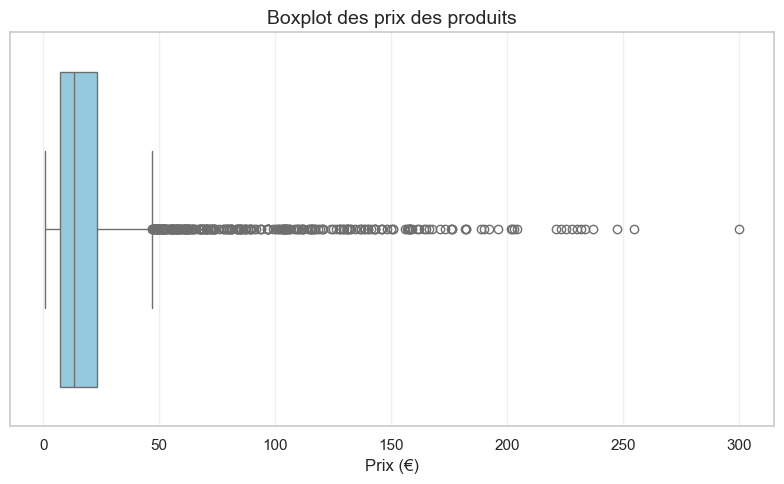

In [19]:
# Visualisation via un boxplot des prix des produits
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_products['price'], color='skyblue')

plt.title("Boxplot des prix des produits", fontsize=14)
plt.xlabel("Prix (€)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.show()


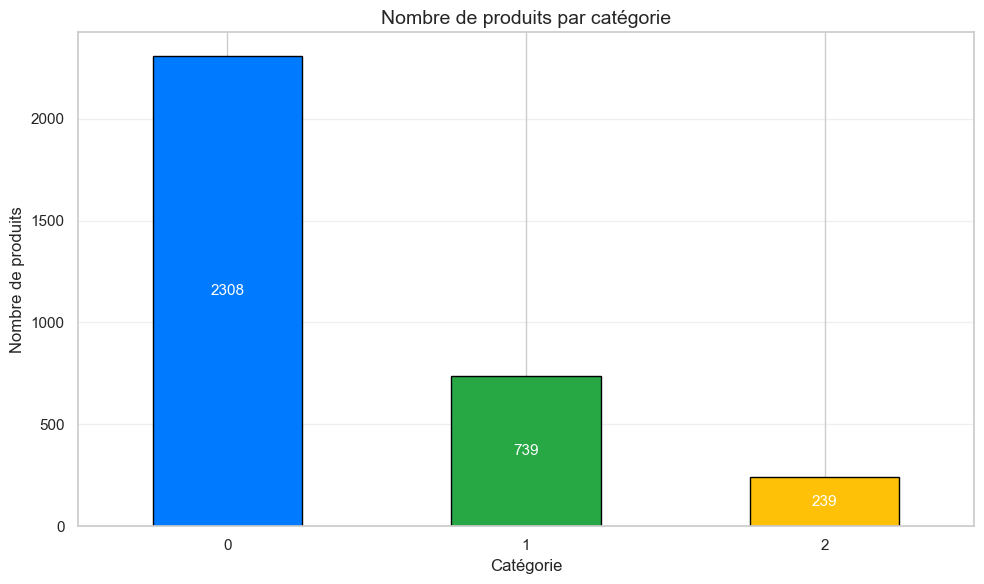

In [20]:
# Visualisation via un graphique à barres pour comparer les types de produits par catégorie

# Comptage des produits par catégorie
produits_par_categorie = df_products['categ'].value_counts().sort_index()

# Définition des couleurs (une par catégorie, dans l'ordre des index 0, 1, 2)
couleurs = ['#007bff', '#28a745', '#ffc107']  # bleu, vert, jaune

# Création du graphique
plt.figure(figsize=(10, 6))
bars = produits_par_categorie.plot(kind='bar', color=couleurs, edgecolor='black')

# Ajout des valeurs à l’intérieur des barres
for i, val in enumerate(produits_par_categorie):
    bars.text(i, val / 2, str(val), ha='center', va='center', fontsize=11, color='white')

# Mise en forme
plt.title('Nombre de produits par catégorie', fontsize=14)
plt.xlabel('Catégorie', fontsize=12)
plt.ylabel('Nombre de produits', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.4 - Analyse exploratoire du fichier transactions.csv</h3>
</di>


Le fichier `transactions.csv` contient l’historique des transactions effectuées par les clients sur le site.

Nous allons ici :
- vérifier la structure des colonnes et les types de données,
- détecter d’éventuelles valeurs manquantes ou doublons,
- inspecter les variables clés : `id_prod`, `client_id`, `date`, `session_id`,
- identifier d’éventuelles anomalies ou incohérences dans les valeurs.


In [23]:
# Dimensions du dataset
print(f"Le tableau comporte {df_transactions.shape[0]} observations")
print(f"Le tableau comporte {df_transactions.shape[1]} colonnes\n")

# Aperçu des premières lignes du dataset transactions.csv
print("Les 5 premières lignes de la table TRANSACTIONS :")
display(df_transactions.head())


Le tableau comporte 1048575 observations
Le tableau comporte 4 colonnes

Les 5 premières lignes de la table TRANSACTIONS :


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [24]:
# Structure générale
print("Informations sur df_transactions :")
df_transactions.info()

# Valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df_transactions.isnull().sum())

# Doublons
print("\nNombre de lignes dupliquées :")
print(df_transactions.duplicated().sum())


Informations sur df_transactions :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB

Valeurs manquantes par colonne :
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

Nombre de lignes dupliquées :
361040


In [25]:
# Visualisation du dataframe 
print(df_transactions)

        id_prod                        date session_id client_id
0        0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1        0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2        0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3        0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4        0_1358  2021-03-01 00:05:18.801198        s_5    c_2033
...         ...                         ...        ...       ...
1048570     NaN                         NaN        NaN       NaN
1048571     NaN                         NaN        NaN       NaN
1048572     NaN                         NaN        NaN       NaN
1048573     NaN                         NaN        NaN       NaN
1048574     NaN                         NaN        NaN       NaN

[1048575 rows x 4 columns]


In [26]:
# Suppression des lignes contenant des valeurs manquantes
df_transactions.dropna(inplace=True)

# Vérification post-nettoyage
print("Après suppression des lignes vides :")
print(f"\nNombre d'observations restantes : {df_transactions.shape[0]}")
print("\nValeurs manquantes restantes par colonnes :")
print(df_transactions.isnull().sum())


Après suppression des lignes vides :

Nombre d'observations restantes : 687534

Valeurs manquantes restantes par colonnes :
id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


In [27]:
# Visualisation du dataframe 
print(df_transactions)

       id_prod                        date session_id client_id
0       0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1       0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2       0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3       0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4       0_1358  2021-03-01 00:05:18.801198        s_5    c_2033
...        ...                         ...        ...       ...
687529   1_508  2023-02-28 23:49:03.148402   s_348444    c_3573
687530    2_37  2023-02-28 23:51:29.318531   s_348445      c_50
687531   1_695  2023-02-28 23:53:18.929676   s_348446     c_488
687532  0_1547  2023-02-28 23:58:00.107815   s_348447    c_4848
687533  0_1398  2023-02-28 23:58:30.792755   s_348435    c_3575

[687534 rows x 4 columns]


In [28]:
# Nombre d'éléments uniques
print("Nombre de produits uniques :", df_transactions['id_prod'].nunique())
print("Nombre de clients uniques :", df_transactions['client_id'].nunique())
print("Nombre de sessions uniques :", df_transactions['session_id'].nunique())

Nombre de produits uniques : 3265
Nombre de clients uniques : 8600
Nombre de sessions uniques : 345505


In [29]:
# Conversion de la colonne date
df_transactions['date'] = pd.to_datetime(df_transactions['date'])

# Période couverte
print("Période couverte :", df_transactions['date'].min(), "→", df_transactions['date'].max())

# Distribution annuelle
df_transactions['year'] = df_transactions['date'].dt.year
print("\nNombre de transactions par année :")
print(df_transactions['year'].value_counts().sort_index())

Période couverte : 2021-03-01 00:01:07.843138 → 2023-02-28 23:58:30.792755

Nombre de transactions par année :
year
2021    286671
2022    346380
2023     54483
Name: count, dtype: int64


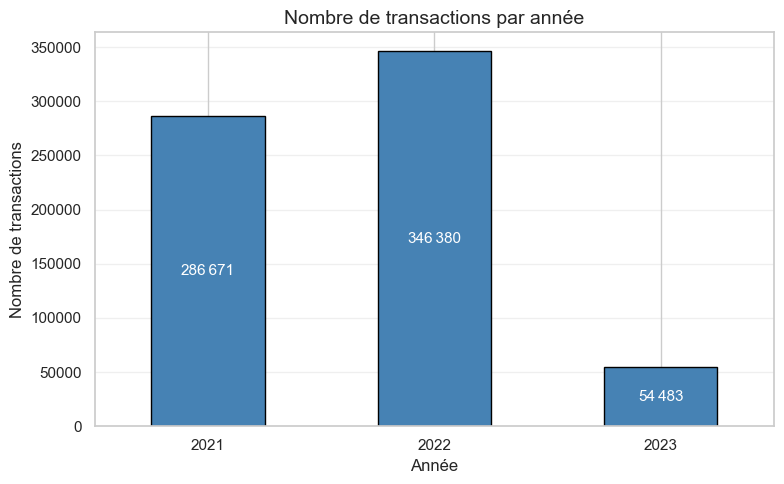

In [30]:
# Visualisation via un graphique à barres du nombre de transactions par année

# Comptage des transactions par année
transactions_par_annee = df_transactions['year'].value_counts().sort_index()

# Graphique à barres
plt.figure(figsize=(8, 5))
bars = transactions_par_annee.plot(kind='bar', color='steelblue', edgecolor='black')

# Affichage des valeurs sur les barres
for i, val in enumerate(transactions_par_annee):
    bars.text(i, val / 2, f"{val:,}".replace(",", "\u202f"), ha='center', va='center', color='white', fontsize=11)

plt.title("Nombre de transactions par année", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre de transactions", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.5 - Analyse exploratoire du fichier customers.csv</h3>
</div>

Le fichier `customers.csv` contient des informations démographiques sur les clients de la librairie.  
Chaque ligne correspond à un client identifié par `client_id`, avec les variables suivantes :
- `sex` : genre du client (f = femme, m = homme),
- `birth` : année de naissance.

Nous allons ici :
- vérifier les types et la complétude des données,
- analyser la distribution des âges et des genres,
- détecter d'éventuelles incohérences ou doublons.


In [33]:
# Dimensions, structure et qualité des données

# Dimensions
print(f"Le tableau comporte {df_customers.shape[0]} observations")
print(f"Le tableau comporte {df_customers.shape[1]} colonnes\n")

# Aperçu
print("Les 5 premières lignes de la table CUSTOMERS :")
display(df_customers.head())

# Structure
print("\nInformations sur la table CUSTOMERS :")
df_customers.info()

# Valeurs manquantes et doublons
print("\nValeurs manquantes :")
print(df_customers.isnull().sum())

print("\nNombre de doublons :")
print(df_customers.duplicated().sum())

Le tableau comporte 8621 observations
Le tableau comporte 3 colonnes

Les 5 premières lignes de la table CUSTOMERS :


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943



Informations sur la table CUSTOMERS :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB

Valeurs manquantes :
client_id    0
sex          0
birth        0
dtype: int64

Nombre de doublons :
0


In [34]:
# Répartition par genre des clients

# Nombre de clients par genre
print("Répartition du nombre de clients par sexe :")
print(df_customers['sex'].value_counts().apply(lambda x: f"{x:,}".replace(",", "\u202f")))

# En pourcentage
print("\nRépartition en pourcentage :")
print((df_customers['sex'].value_counts(normalize=True) * 100).round(2))

Répartition du nombre de clients par sexe :
sex
f    4 490
m    4 131
Name: count, dtype: object

Répartition en pourcentage :
sex
f    52.08
m    47.92
Name: proportion, dtype: float64


In [35]:
# Analyse de l'âge des clients

# Calcul de l'âge
df_customers['age'] = 2023 - df_customers['birth']

# Statistiques descriptives sur l'âge
print("Statistiques sur l'âge des clients :")
print(df_customers['age'].describe().round(1))

Statistiques sur l'âge des clients :
count    8621.0
mean       44.7
std        16.9
min        19.0
25%        31.0
50%        44.0
75%        57.0
max        94.0
Name: age, dtype: float64


In [36]:
# tableau synthétique de stats descriptives groupées par sexe
df_customers.groupby('sex')['age'].describe().round(1)


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
f,4490.0,45.0,17.1,19.0,31.0,44.0,57.0,94.0
m,4131.0,44.4,16.7,19.0,31.0,43.0,57.0,94.0


In [37]:
# Calcul des bornes IQR pour l'âge
Q1_age = df_customers['age'].quantile(0.25)
Q3_age = df_customers['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

borne_basse_age = Q1_age - 1.5 * IQR_age
borne_haute_age = Q3_age + 1.5 * IQR_age

print(f"Borne basse : {borne_basse_age:.1f} ans")
print(f"Borne haute : {borne_haute_age:.1f} ans")

# Identification des outliers
outliers_age = df_customers[
    (df_customers['age'] < borne_basse_age) | 
    (df_customers['age'] > borne_haute_age)
]

print(f"\nNombre de clients considérés comme outliers sur l'âge : {outliers_age.shape[0]}")
display(outliers_age.sort_values(by='age', ascending=False).head())


Borne basse : -8.0 ans
Borne haute : 96.0 ans

Nombre de clients considérés comme outliers sur l'âge : 0


,client_id,sex,birth,age


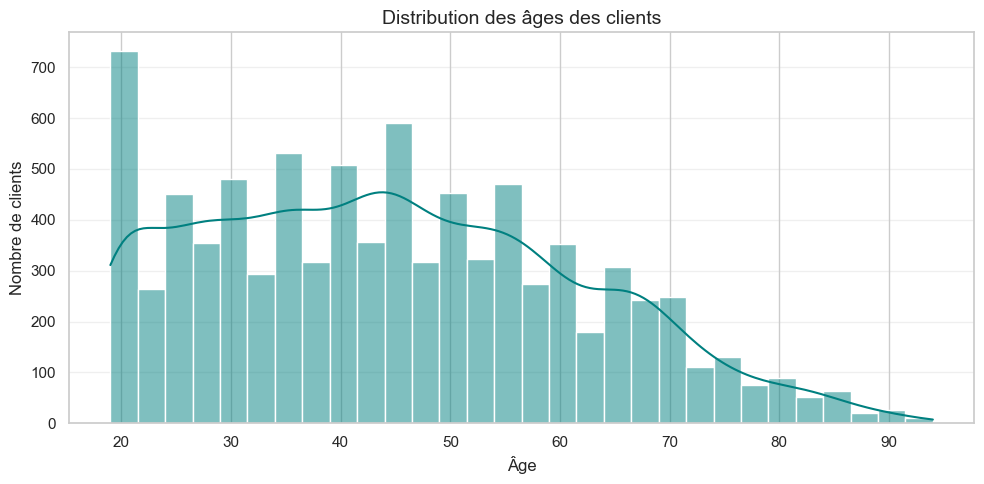

In [38]:
# Visualisation des âges des clients via un histogramme

plt.figure(figsize=(10, 5))
sns.histplot(df_customers['age'], bins=30, kde=True, color='teal')

plt.title("Distribution des âges des clients", fontsize=14)
plt.xlabel("Âge", fontsize=12)
plt.ylabel("Nombre de clients", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


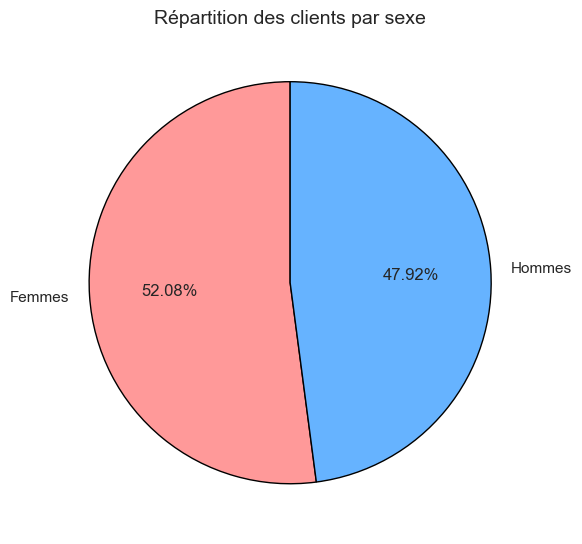

In [39]:
# Visualisation de la répartition hommes/femmes 

# Répartition hommes / femmes
repartition_sexe = df_customers['sex'].value_counts()

# Étiquettes avec % automatique
labels = ['Femmes', 'Hommes']
colors = ['#ff9999', '#66b3ff'] 

plt.figure(figsize=(6, 6))
plt.pie(
    repartition_sexe,
    labels=labels,
    autopct='%.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Répartition des clients par sexe", fontsize=14)
plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.6 - Préparation et jointure des données</h3>
</div>


### Construction de la table finale `df_merged`

Cette étape consiste à créer un **jeu de données consolidé** à partir des trois sources disponibles (`transactions.csv`, `products.csv`, `customers.csv`), 


Nous allons fusionner les 3 fichiers (`products`, `transactions`, `customers`) afin d’obtenir une vue complète :

- Tous les **clients** sont conservés, même ceux n’ayant jamais passé de commande,
- Tous les **produits** sont conservés, même ceux qui n’ont jamais été vendus,
- Toutes les **transactions** sont enrichies avec les informations produits et clients quand elles existent.

Cela nous permettra :
- d’analyser les ventes réelles (`id_prod` non nul),
- d’identifier les produits du catalogue jamais vendus,
- de repérer les clients inactifs.

Les valeurs `NaN` seront utilesées pour repérer ces cas.

Cela permettra ensuite de calculer le chiffre d’affaires, d’analyser les catégories les plus achetées, ou d'étudier les corrélations avec les profils clients.


In [42]:
# Étape 1 – Jointure produits + transactions
# => on garde tous les produits (y compris ceux jamais vendus) 
#et potentiellement on perd les transactions pour lesquels l'id_produit n'est n'est pas dans la base Products
df_prod_tx = pd.merge(
    df_products,
    df_transactions,
    on='id_prod',
    how='left'  # tous les produits du catalogue sont conservés
)

# Vérification rapide
print(f"Nombre de lignes après jointure avec products : {df_prod_tx.shape[0]}")
print("Aperçu des premières lignes :")
display(df_prod_tx.head())


Nombre de lignes après jointure avec products : 687555
Aperçu des premières lignes :


,id_prod,price,categ,date,session_id,client_id,year
0,0_1421,19.99,0,2021-03-01 04:13:00.107748,s_101,c_8533,2021.0
1,0_1421,19.99,0,2021-03-01 13:48:20.214075,s_285,c_5299,2021.0
2,0_1421,19.99,0,2021-03-01 15:07:42.730079,s_317,c_8024,2021.0
3,0_1421,19.99,0,2021-03-02 03:39:21.811833,s_563,c_7702,2021.0
4,0_1421,19.99,0,2021-03-02 19:09:41.789425,s_850,c_4057,2021.0


In [43]:
# vérification du nombre de produits figurant dans cette base fusionnée
print(f"Nombre de produits identifiés dans la base fusionnée : {df_prod_tx['id_prod'].nunique()}")

Nombre de produits identifiés dans la base fusionnée : 3286


In [44]:
# Vérification : transactions contenant un id_prod non répertorié dans le catalogue

df_tx_prod_check = pd.merge(
    df_products,
    df_transactions,
    on='id_prod',
    how='right'  # on garde toutes les transactions, même celles avec produit inconnu
)

# Transactions dont le produit est inconnu (pas de correspondance dans products)
transactions_sans_produit = df_tx_prod_check[df_tx_prod_check['price'].isna()]

# Affichage
print(f"Nombre de transactions avec un id_prod absent du catalogue : {transactions_sans_produit.shape[0]}")
display(transactions_sans_produit[['id_prod', 'client_id', 'date', 'session_id']].head())


Nombre de transactions avec un id_prod absent du catalogue : 0


,id_prod,client_id,date,session_id


Après vérification, on constate que toutes les transactions concernent des produits figuirant de la base PRODUCTS

In [46]:
# Étape 2 – Jointure avec les clients (outer join)
# => on garde tous les clients (y compris ceux qui n’ont rien acheté) et tous les produits (même ceux non-achetés)
df_merged = pd.merge(
    df_customers[['client_id', 'sex', 'age']],
    df_prod_tx,
    on='client_id',
    how='outer'  # on garde tous les clients et tous les produits
)

# Vérification
print("Dimensions du DataFrame final :", df_merged.shape)
print("\nAperçu des données fusionnées :")
display(df_merged.head())


Dimensions du DataFrame final : (687576, 9)

Aperçu des données fusionnées :


,client_id,sex,age,id_prod,price,categ,date,session_id,year
0,c_1,m,68.0,0_513,11.99,0.0,2021-07-21 22:41:38.769525,s_65433,2021.0
1,c_1,m,68.0,0_513,11.99,0.0,2022-03-21 22:41:38.769525,s_182481,2022.0
2,c_1,m,68.0,0_513,11.99,0.0,2022-10-21 22:41:38.769525,s_286029,2022.0
3,c_1,m,68.0,0_513,11.99,0.0,2022-12-21 22:41:38.769525,s_315508,2022.0
4,c_1,m,68.0,1_433,18.99,1.0,2021-10-15 11:28:27.540834,s_105105,2021.0


In [47]:
# Vérification des valeurs manquantes
print("Valeurs manquantes après jointures :")
print(df_merged.isnull().sum())


Valeurs manquantes après jointures :
client_id     21
sex           21
age           21
id_prod       21
price         21
categ         21
date          42
session_id    42
year          42
dtype: int64


In [48]:
# Nombre de clients n'ayant effectué aucune transaction
nb_clients_inactifs = df_merged[df_merged['id_prod'].isna()]['client_id'].nunique()
print(f"Nombre de clients n'ayant effectué aucune transaction : {nb_clients_inactifs}")

# Liste détaillée de ces clients
df_merged[df_merged['id_prod'].isna()]


Nombre de clients n'ayant effectué aucune transaction : 21


,client_id,sex,age,id_prod,price,categ,date,session_id,year
18399,c_1223,m,60.0,NaN,NaN,NaN,NaT,NaN,NaN
167262,c_2706,f,56.0,NaN,NaN,NaN,NaT,NaN,NaN
191551,c_3017,f,31.0,NaN,NaN,NaN,NaT,NaN,NaN
225851,c_3443,m,64.0,NaN,NaN,NaN,NaT,NaN,NaN
240172,c_3526,m,67.0,NaN,NaN,NaN,NaT,NaN,NaN
261001,c_3789,f,26.0,NaN,NaN,NaN,NaT,NaN,NaN
282271,c_4086,f,31.0,NaN,NaN,NaN,NaT,NaN,NaN
305952,c_4358,m,24.0,NaN,NaN,NaN,NaT,NaN,NaN
309172,c_4406,f,25.0,NaN,NaN,NaN,NaT,NaN,NaN
312791,c_4447,m,67.0,NaN,NaN,NaN,NaT,NaN,NaN


In [49]:
# Nombre de produits jamais achetés
nb_produits_non_vendus = df_merged[df_merged['client_id'].isna()]['id_prod'].nunique()
print(f"Nombre de produits jamais achetés : {nb_produits_non_vendus}")

# Liste détaillée avec toutes les colonnes disponibles
produits_non_vendus = df_merged[df_merged['client_id'].isna()].drop_duplicates(subset=['id_prod'])

display(produits_non_vendus)


Nombre de produits jamais achetés : 21


,client_id,sex,age,id_prod,price,categ,date,session_id,year
687555,NaN,NaN,NaN,0_1016,35.06,0.0,NaT,NaN,NaN
687556,NaN,NaN,NaN,0_1780,1.67,0.0,NaT,NaN,NaN
687557,NaN,NaN,NaN,0_1062,20.08,0.0,NaT,NaN,NaN
687558,NaN,NaN,NaN,0_1119,2.99,0.0,NaT,NaN,NaN
687559,NaN,NaN,NaN,0_1014,1.15,0.0,NaT,NaN,NaN
687560,NaN,NaN,NaN,1_0,31.82,1.0,NaT,NaN,NaN
687561,NaN,NaN,NaN,0_1318,20.92,0.0,NaT,NaN,NaN
687562,NaN,NaN,NaN,0_1800,22.05,0.0,NaT,NaN,NaN
687563,NaN,NaN,NaN,0_1645,2.99,0.0,NaT,NaN,NaN
687564,NaN,NaN,NaN,0_322,2.99,0.0,NaT,NaN,NaN


### Analyse des valeurs manquantes après jointures

Les seules valeurs manquantes détectées dans `df_merged` concernent les colonnes liées aux ventes :  
`id_prod`, `price`, `categ`, `date`, `session_id`, `year`.

Elles concernent deux cas distincts :

- **21 lignes** avec `id_prod` manquant : il s’agit de **clients présents dans la base** mais **n’ayant effectué aucune transaction**.  
  Ces clients apparaissent avec des `NaN` sur les colonnes liées aux produits et à la transaction.  
  ➤ Ces profils peuvent être intéressants à cibler dans le cadre d’une **campagne de relance**.

- **21 lignes** avec `client_id` manquant : il s’agit de **produits du catalogue qui n’ont jamais été achetés**.  
  Ces lignes contiennent les informations produits (`price`, `categ`) mais aucune information client.  
  ➤ Cela permet d’identifier les **références non performantes** à retravailler ou retirer.

Aucun `NaN` n’a été détecté dans les données démographiques (`client_id`, `sex`, `age`) pour les clients actifs, ce qui confirme la bonne qualité de la base avons clieé.

Nou listons ci-dessous :
- le **nombre de clients inactifs** identifiés,
- le **nombre de produits jamais vendus**,
- ainsi que la **list clients inactifs ete détaill invendusée** de ces produits.



<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.7 - Indicateurs globaux</h3>
</div>


Cette section vise à calculer les **indicateurs clés (KPIs)** de l’activité, à partir du fichier fusionné `df_merged`.  
Ces premiers chiffres permettent d’obtenir une vision macro de l’activité commerciale.

Les indicateurs calculés sont :
- le **chiffre d’affaires total** (somme des prix),
- le **nombre total de transactions**,
- le **nombre total de produits vendus**,
- le **nombre de clients uniques**,
- le **nombre de produits référencés** réellement vendus,
- le **Nombre de sessions uniques**.


In [53]:
print("INDICATEURS GLOBAUX\n")

# Base : transactions réelles uniquement
df_transactions_valides = df_merged[df_merged['client_id'].notna() & df_merged['id_prod'].notna()]

# Chiffre d'affaires total
ca_total = df_transactions_valides['price'].sum()
print(f"Chiffre d'affaires total : {ca_total:,.2f} €".replace(",", "\u202f"))

# Nombre de transactions
nb_transactions = df_transactions_valides.shape[0]
print(f"Nombre total de transactions : {nb_transactions:,}".replace(",", "\u202f"))

# Nombre de références produits dans le catalogue
taille_catalogue = df_products['id_prod'].nunique()
print(f"Nombre total de références produits au catalogue : {taille_catalogue:,}".replace(",", "\u202f"))

# Nombre de références produits effectivement vendues
nb_produits_uniques_vendus = df_transactions_valides['id_prod'].nunique()
print(f"Nombre de références produits effectivement vendues : {nb_produits_uniques_vendus:,}".replace(",", "\u202f"))

# Nombre de produits jamais achetés
nb_produits_non_vendus = taille_catalogue - nb_produits_uniques_vendus
print(f"Nombre de produits jamais achetés : {nb_produits_non_vendus}")

# Nombre de clients actifs
nb_clients_uniques = df_transactions_valides['client_id'].nunique()
print(f"Nombre de clients ayant effectué au moins une transaction : {nb_clients_uniques:,}".replace(",", "\u202f"))

# Nombre de clients inactifs
nb_clients_total = df_customers['client_id'].nunique()
nb_clients_inactifs = nb_clients_total - nb_clients_uniques
print(f"Nombre de clients n'ayant effectué aucune transaction : {nb_clients_inactifs}")

# Nombre de sessions uniques
nb_sessions = df_transactions_valides['session_id'].nunique()
print(f"Nombre de sessions uniques : {nb_sessions:,}".replace(",", "\u202f"))


INDICATEURS GLOBAUX

Chiffre d'affaires total : 12 027 663.10 €
Nombre total de transactions : 687 534
Nombre total de références produits au catalogue : 3 286
Nombre de références produits effectivement vendues : 3 265
Nombre de produits jamais achetés : 21
Nombre de clients ayant effectué au moins une transaction : 8 600
Nombre de clients n'ayant effectué aucune transaction : 21
Nombre de sessions uniques : 345 505


In [54]:
# tableau synthétique

# Dictionnaire des KPI
kpis = {
    "Chiffre d'affaires total (€)": ca_total,
    "Nombre total de transactions": nb_transactions,
    "Nombre total de références produits au catalogue": taille_catalogue,
    "Références produits vendues": nb_produits_uniques_vendus,
    "Produits jamais vendus": nb_produits_non_vendus,
    "Clients actifs (ayant acheté)": nb_clients_uniques,
    "Clients inactifs": nb_clients_inactifs,
    "Sessions uniques": nb_sessions
}

# Transformation en DataFrame
df_kpi = pd.DataFrame.from_dict(kpis, orient='index', columns=["Valeur"])
df_kpi.index.name = "Indicateur"

# Format avec espace insécable comme séparateur de milliers (à la française)
df_kpi["Valeur"] = df_kpi["Valeur"].apply(lambda x: f"{x:,.0f}".replace(",", "\u202f"))

# Mise en forme stylisée
df_kpi_styled = df_kpi.style \
    .set_properties(**{"font-size": "14px"}) \
    .set_caption("Indicateurs globaux de l'activité :")

display(df_kpi_styled)


,Valeur
Indicateur,
Chiffre d'affaires total (€),12 027 663
Nombre total de transactions,687 534
Nombre total de références produits au catalogue,3 286
Références produits vendues,3 265
Produits jamais vendus,21
Clients actifs (ayant acheté),8 600
Clients inactifs,21
Sessions uniques,345 505


### Remarque méthodologique – Base utilisée pour les analyses à venir

À partir de cette étape, toutes les analyses seront réalisées **uniquement sur les transactions réellement effectuées**, c’est-à-dire les lignes du DataFrame `df_merged` :

- pour lesquelles un **client est identifié** (`client_id` non nul),
- et un **produit a bien été vendu** (`id_prod` non nul).

Nous avons donc créé un DataFrame filtré, appelé `df_transactions_valides`, qui servira de **base unique de travail** pour toutes les analyses suivantes (chiffre d’affaires, catégories, profils clients, etc.).

Ce filtrage exclut :
- les **clients inactifs** (jamais acheteurs),
- les **produits du catalogue jamais vendus**,
- les lignes générées lors de la jointure complète mais sans correspondance réelle.


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.8 - Évolution du chiffre d'affaires dans le temps</h3>
</div>


Dans cette section, nous analysons l'évolution du **chiffre d'affaires mensuel**, afin de mettre en évidence d’éventuelles **tendances saisonnières**, des **pics d'activité**, ou au contraire des périodes de creux.

Nous utilisons :
- le DataFrame `df_transactions_valides` filtré sur les transactions réelles uniquement,
- un regroupement par **mois** (extrait de la colonne `date`),
- une **moyenne mobile sur 3 mois** pour lisser les variations mensuelles.


In [58]:
# Création d'une copie propre
df_transactions_valides = df_merged[df_merged['client_id'].notna() & df_merged['id_prod'].notna()].copy()

# Création de la colonne "mois"
df_transactions_valides['mois'] = df_transactions_valides['date'].dt.to_period('M').dt.to_timestamp()

# Calcul du chiffre d'affaires par mois
ca_mensuel = df_transactions_valides.groupby('mois')['price'].sum().reset_index()

# Ajout d'une moyenne mobile sur 3 mois
ca_mensuel['CA_moyenne_mobile_3M'] = ca_mensuel['price'].rolling(window=3).mean()

# Aperçu
display(ca_mensuel.head())


,mois,price,CA_moyenne_mobile_3M
0,2021-03-01,482440.61,NaN
1,2021-04-01,476109.30,NaN
2,2021-05-01,492943.47,483831.126667
3,2021-06-01,484088.56,484380.443333
4,2021-07-01,482835.40,486622.476667


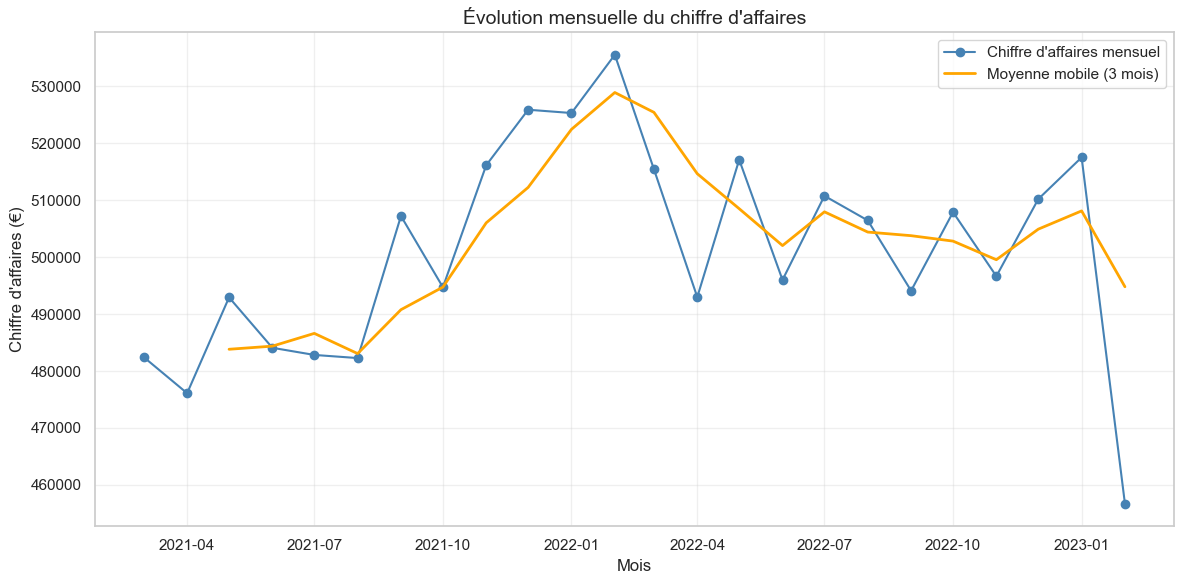

In [59]:
plt.figure(figsize=(12, 6))

# Courbe du chiffre d'affaires
plt.plot(ca_mensuel['mois'], ca_mensuel['price'], label="Chiffre d'affaires mensuel", color='steelblue', marker='o')

# Courbe de la moyenne mobile
plt.plot(ca_mensuel['mois'], ca_mensuel['CA_moyenne_mobile_3M'], label="Moyenne mobile (3 mois)", color='orange', linewidth=2)

plt.title("Évolution mensuelle du chiffre d'affaires", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interprétation

La courbe permet de visualiser clairement l’évolution du chiffre d’affaires mois par mois.

On observe :
- une montée en charge progressive à partir du lancement en mars 2021,
- un pic d’activité visible début 2022,
- une tendance à la baisse au cours de l’année 2022,
- une baisse très nette en début 2023, cohérente avec la couverture partielle de la période (janvier-février uniquement).

La **moyenne mobile sur 3 mois** permet de lisser les variations ponctuelles et de mieux faire ressortir la tendance générale.


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.9 - Chiffre d'affaires par catégorie de produits</h3>
</div>


Dans cette section, nous analysons la contribution des **différentes catégories de produits** au chiffre d'affaires global.

Chaque transaction est associée à une variable `categ` :
- 0, 1 ou 2, représentant des grandes familles de produits,
- nous n'avons pas le libellé exact, mais nous pouvons comparer leur poids économique relatif.

L’objectif est d’identifier :
- les catégories **les plus contributrices au chiffre d’affaires**,
- les éventuels déséquilibres à prendre en compte dans l’offre.


In [63]:
# Agrégation du chiffre d'affaires par catégorie
ca_par_categ = df_transactions_valides.groupby('categ')['price'].sum().sort_index()

# Part en pourcentage
part_par_categ = (ca_par_categ / ca_par_categ.sum() * 100).round(2)

# Fusion dans un DataFrame
df_ca_categ = pd.DataFrame({
    "Chiffre d'affaires (€)": ca_par_categ.round(2),
    "Part du CA (%)": part_par_categ
})

display(df_ca_categ)



,Chiffre d'affaires (€),Part du CA (%)
categ,,
0.0,4419730.97,36.75
1.0,4827657.11,40.14
2.0,2780275.02,23.12


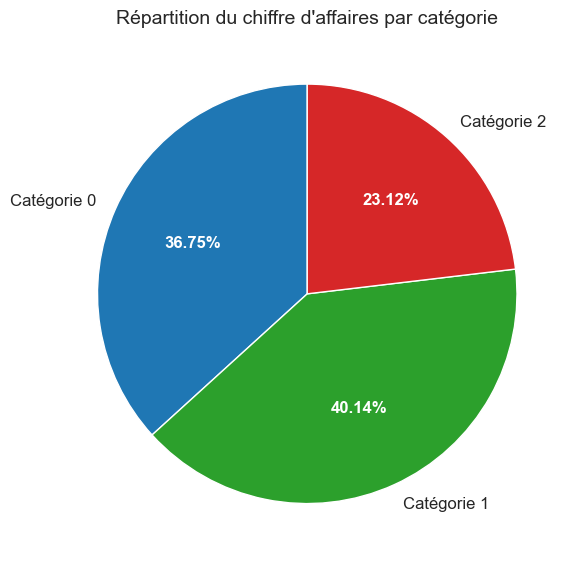

In [64]:
# Visualisation graphique
labels = [f"Catégorie {int(i)}" for i in df_ca_categ.index]

# Couleurs par catégorie : 0 → bleu, 1 → vert, 2 → rouge
couleurs_categories = {
    0.0: '#1f77b4',
    1.0: '#2ca02c',
    2.0: '#d62728'
}

# Liste des couleurs dans l'ordre
colors = [couleurs_categories.get(i, 'grey') for i in df_ca_categ.index]

# Camembert
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    df_ca_categ["Chiffre d'affaires (€)"],
    labels=labels,
    autopct='%.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 12}  # labels (catégories) en noir par défaut
)

# Texte autopct en blanc
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title("Répartition du chiffre d'affaires par catégorie", fontsize=14)
plt.tight_layout()
plt.show()


### Interprétation

La répartition du chiffre d’affaires par catégorie montre une **contribution relativement équilibrée**, avec toutefois une légère domination de la **catégorie 1** :

- **Catégorie 1** représente **40,14 %** du chiffre d’affaires total (soit environ 4,83 M€),
- suivie de **la catégorie 0** avec **36,75 %** (4,42 M€),
- et enfin la **catégorie 2**, qui reste significative avec **23,12 %** (2,78 M€).

Ce découpage suggère que **les trois catégories sont bien représentées commercialement**, et mériteraient d’être conservées dans l’offre, même si :
- la **catégorie 2 pourrait faire l’objet d’une analyse plus approfondie** (produits à repositionner ou à relancer ?),
- la **catégorie 1** semble tirer l’activité, et pourrait être valorisée davantage (offres, recommandations, mises en avant).

Cette analyse pourra être enrichie ensuite par une comparaison :
- du **nombre de références par catégorie** dans le catalogue,
- et du **nombre de références réellement vendues**.


In [66]:
# Nombre de produits vendus (volume) par catégorie
volume_par_categ = df_transactions_valides.groupby('categ')['id_prod'].count()

# CA par catégorie (repris du calcul précédent)
ca_par_categ = df_transactions_valides.groupby('categ')['price'].sum()

# Prix moyen unitaire = CA / nombre de produits vendus
prix_moyen_categ = (ca_par_categ / volume_par_categ).round(2)

# Assemblage dans un DataFrame
df_volume_ca = pd.DataFrame({
    "Produits vendus (volume)": volume_par_categ,
    "Chiffre d'affaires (€)": ca_par_categ.round(2),
    "Prix moyen (€)": prix_moyen_categ
})

display(df_volume_ca)


,Produits vendus (volume),Chiffre d'affaires (€),Prix moyen (€)
categ,,,
0.0,415459,4419730.97,10.64
1.0,235592,4827657.11,20.49
2.0,36483,2780275.02,76.21


### Analyse croisée volume vs chiffre d’affaires par catégorie

Cette analyse croisée révèle des **profils très différenciés** entre les trois catégories de produits :

- **Catégorie 0** est la plus vendue en volume (**415 459 unités**), mais avec un **prix moyen très bas** (**10,64 €**).  
  ➤ Il s'agit probablement de **produits d'appel** ou à faible valeur unitaire, vendus massivement.

- **Catégorie 1** se positionne comme une offre intermédiaire :  
  **235 592 produits vendus**, mais un **prix moyen plus élevé** (**20,49 €**).  
  ➤ Elle génère à elle seule le **plus fort chiffre d’affaires** (près de 4,83 M€).

- **Catégorie 2** est **très haut de gamme** : seulement **36 483 unités vendues**, mais avec un **prix moyen élevé de 76,21 €**.  
  ➤ Ce sont probablement des **produits premium ou spécialisés**, à forte valeur ajoutée.

Cette répartition suggère une **stratégie produit différenciée** :  
- une **catégorie de masse (0)**,  
- une **catégorie cœur de gamme (1)**,  
- une **catégorie à forte marge (2)**.

Ces insights pourront guider des décisions sur la **mise en avant**, **le pricing**, ou encore **les campagnes marketing ciblées par catégorie**.


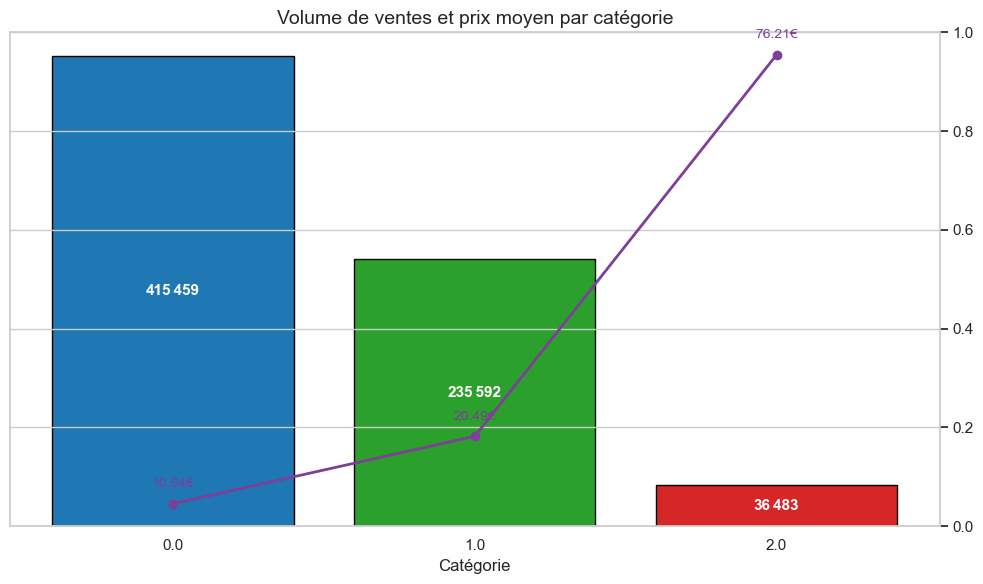

In [68]:
colors_barres = [couleurs_categories.get(c, 'grey') for c in df_volume_ca.index]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barres : volume
bars = ax1.bar(
    df_volume_ca.index.astype(str),
    df_volume_ca["Produits vendus (volume)"],
    color=colors_barres,
    edgecolor='black'
)

# Texte dans les barres
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"{int(height):,}".replace(",", "\u202f"),
        ha='center', va='center',
        color='white',
        fontsize=11,
        fontweight='bold'
    )

# Titre
ax1.set_title("Volume de ventes et prix moyen par catégorie", fontsize=14)

# Suppression de l'axe y gauche
ax1.set_ylabel("")
ax1.set_yticks([])
ax1.tick_params(axis='y', left=False)
ax1.grid(False)

# Axe x
ax1.set_xlabel("Catégorie")

# Supprimer le cadre autour du graphique
for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax1.twinx().spines.values():
    spine.set_visible(False)

# Courbe : prix moyen
ax2 = ax1.twinx()
ax2.plot(
    df_volume_ca.index.astype(str),
    df_volume_ca["Prix moyen (€)"],
    color='#7e3f98',  # violet foncé plus lisible
    marker='o',
    linewidth=2
)

# Valeurs du prix moyen
for i, val in enumerate(df_volume_ca["Prix moyen (€)"]):
    ax2.text(
        i,
        val + 2,
        f"{val:.2f}€",
        ha='center',
        va='bottom',
        color='#7e3f98',
        fontsize=10
    )

# Suppression de l'axe y secondaire
ax2.set_ylabel("")
ax2.set_yticks([])
ax2.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

plt.tight_layout()
plt.show()


Le graphique ci-dessus illustre visuellement la répartition des volumes de ventes (barres) et des prixs moyens (courbe) par catégorie.


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.10 - Nombre de clients actifs par mois</h3>
</div>


Dans cette section, nous analysons le **nombre de clients actifs par mois**, c’est-à-dire le nombre de clients différents ayant effectué au moins une transaction sur la période.

Cela permet de :
- suivre l’évolution de la base client réellement engagée,
- détecter d’éventuelles variations saisonnières ou tendances,
- évaluer l’effet de campagnes marketing ou d’événements ponctuels.

Nous utilisons le DataFrame `df_transactions_valides` pour garantir que seuls les achats réels sont pris en compte.


In [72]:
# Nombre de clients uniques par mois
clients_actifs_par_mois = df_transactions_valides.groupby('mois')['client_id'].nunique().reset_index()
clients_actifs_par_mois.rename(columns={'client_id': 'clients_uniques'}, inplace=True)

# Aperçu
display(clients_actifs_par_mois.head())

,mois,clients_uniques
0,2021-03-01,5676
1,2021-04-01,5674
2,2021-05-01,5644
3,2021-06-01,5659
4,2021-07-01,5672


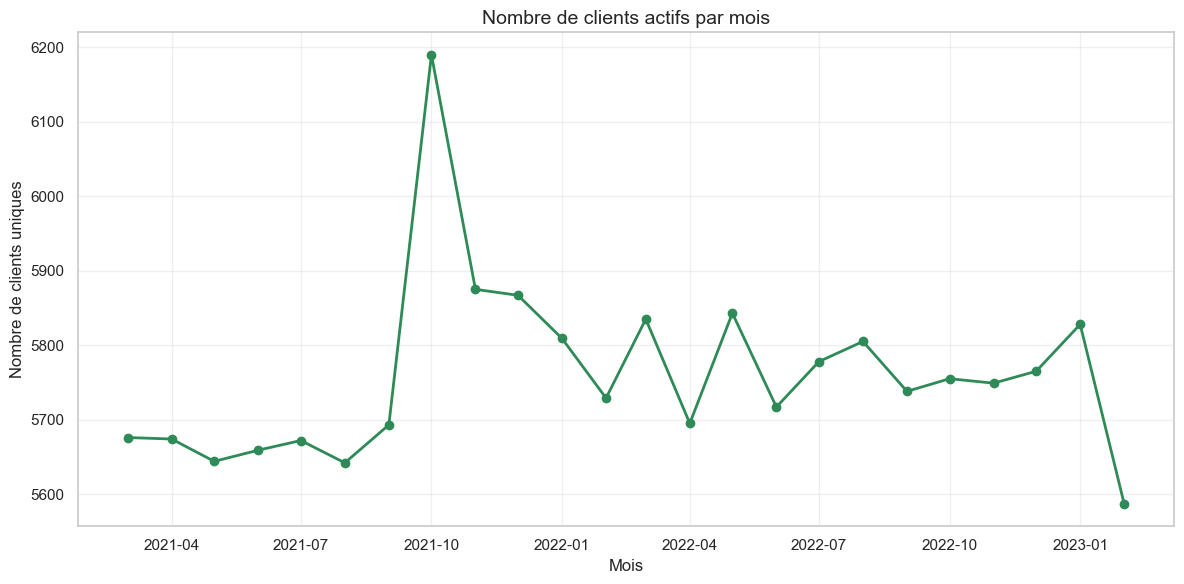

In [73]:
# visualisation graphique
plt.figure(figsize=(12, 6))
plt.plot(clients_actifs_par_mois['mois'], clients_actifs_par_mois['clients_uniques'],
         marker='o', color='seagreen', linewidth=2)

plt.title("Nombre de clients actifs par mois", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Nombre de clients uniques")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interprétation

Le graphique montre que le nombre de **clients actifs mensuels** est relativement stable dans le temps, avec un niveau situé en moyenne entre **5 600 et 5 900 clients uniques** par mois.

On observe toutefois :

- un **pic très net en octobre 2021**, avec plus de **6 180 clients actifs**, qui constitue un **événement exceptionnel** : cela peut correspondre à une opération marketing ponctuelle, une rentrée littéraire, ou une promotion spécifique,
- une **stabilisation après ce pic**, autour de 5 700 à 5 800 clients mensuels,
- une **baisse en janvier-février 2023**, probablement liée à une **couverture partielle de la période** (moins de jours, ou fin de collecte de données).

Cette régularité du nombre de clients actifs montre une **fidélisation assez stable** de la clientèle.  
L’analyse du **prix moyen par client** ou des **fréquences d’achat individuelles** pourra compléter cette lecture.


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.11 - Nombre de transactions et de sessions par mois</h3>
</div>


Dans cette section, nous comparons deux indicateurs clés de l’activité mensuelle :

- le **nombre de transactions** (1 ligne = 1 produit vendu),
- le **nombre de sessions uniques**, c’est-à-dire le nombre de **commandes distinctes** passées par les clients.

Une session peut comprendre **plusieurs produits**, donc plusieurs transactions.  
Cette analyse permet de détecter :
- l’évolution des volumes globaux d’achat,
- le **nombre d’actes d’achat**,
- et, plus tard, le **nombre moyen de produits par session**.


In [77]:
# Groupe par mois pour transactions (déjà présente dans "mois")
transactions_sessions_par_mois = df_transactions_valides.groupby('mois').agg({
    'id_prod': 'count',
    'session_id': pd.Series.nunique
}).reset_index()

transactions_sessions_par_mois.rename(columns={
    'id_prod': 'transactions',
    'session_id': 'sessions_uniques'
}, inplace=True)

display(transactions_sessions_par_mois.head())


,mois,transactions,sessions_uniques
0,2021-03-01,28601,14201
1,2021-04-01,28443,13970
2,2021-05-01,28285,14168
3,2021-06-01,26850,13838
4,2021-07-01,24738,13571


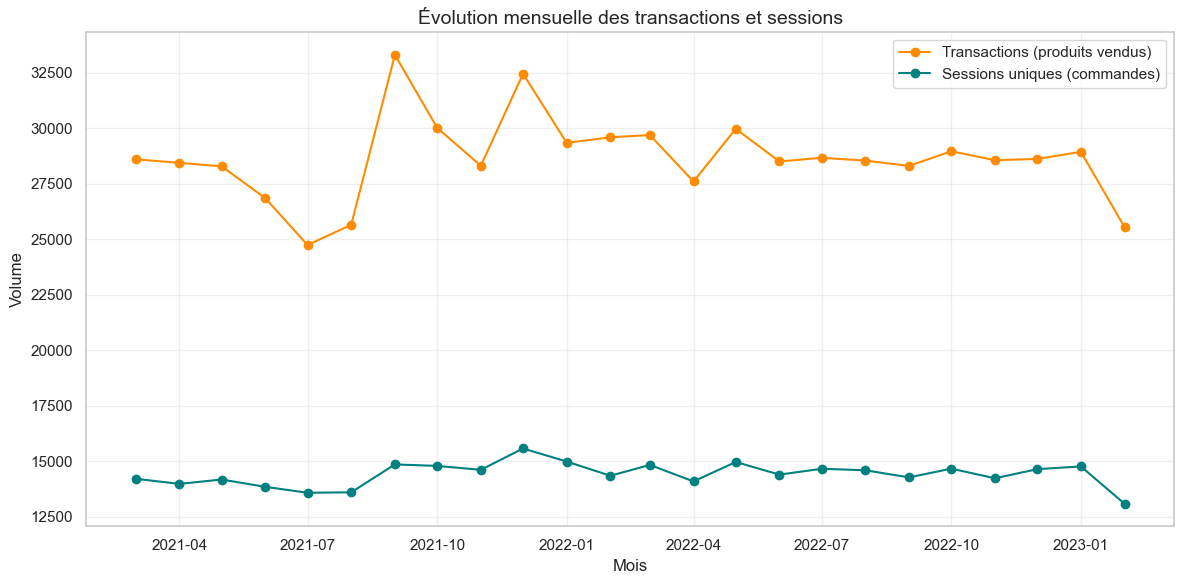

In [78]:
# Visualisation graphique
plt.figure(figsize=(12, 6))

# Transactions (produits vendus)
plt.plot(transactions_sessions_par_mois['mois'], transactions_sessions_par_mois['transactions'],
         label='Transactions (produits vendus)', color='darkorange', marker='o')

# Sessions
plt.plot(transactions_sessions_par_mois['mois'], transactions_sessions_par_mois['sessions_uniques'],
         label='Sessions uniques (commandes)', color='teal', marker='o')

plt.title("Évolution mensuelle des transactions et sessions", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interprétation

Le graphique met en évidence une **activité soutenue et régulière** sur toute la période, avec deux indicateurs distincts :

- le **nombre de transactions** (produits vendus), qui oscille autour de **28 000 à 33 000 par mois**, avec un **pic en octobre 2021** au-delà de **32 500**,
- le **nombre de sessions uniques** (commandes), plus bas comme attendu, autour de **13 000 à 15 000 par mois**.

L’écart entre les deux courbes reste relativement stable, ce qui montre que :
- les clients continuent à **acheter plusieurs produits par session** en moyenne,
- il n'y a pas de changement majeur dans les comportements d'achat par prix.

La hausse marquée en octobre 2021 pourrait correspondre à un **événement spécifique** (promotion, rentrée littéraire, etc.),  
et la baisse en janvier-février 2023 est sans doute liée à une **couverture partielle de la période**.

Ces données sont une bonne base pour calculer le **prix moyen en nombre de produits par session**, mois par mois.


In [80]:
# Calcul du nombre moyen de produits par session
transactions_sessions_par_mois['produits_par_session'] = (
    transactions_sessions_par_mois['transactions'] / transactions_sessions_par_mois['sessions_uniques']
).round(2)

# Aperçu
display(transactions_sessions_par_mois[['mois', 'transactions', 'sessions_uniques', 'produits_par_session']].head())


,mois,transactions,sessions_uniques,produits_par_session
0,2021-03-01,28601,14201,2.01
1,2021-04-01,28443,13970,2.04
2,2021-05-01,28285,14168,2.00
3,2021-06-01,26850,13838,1.94
4,2021-07-01,24738,13571,1.82


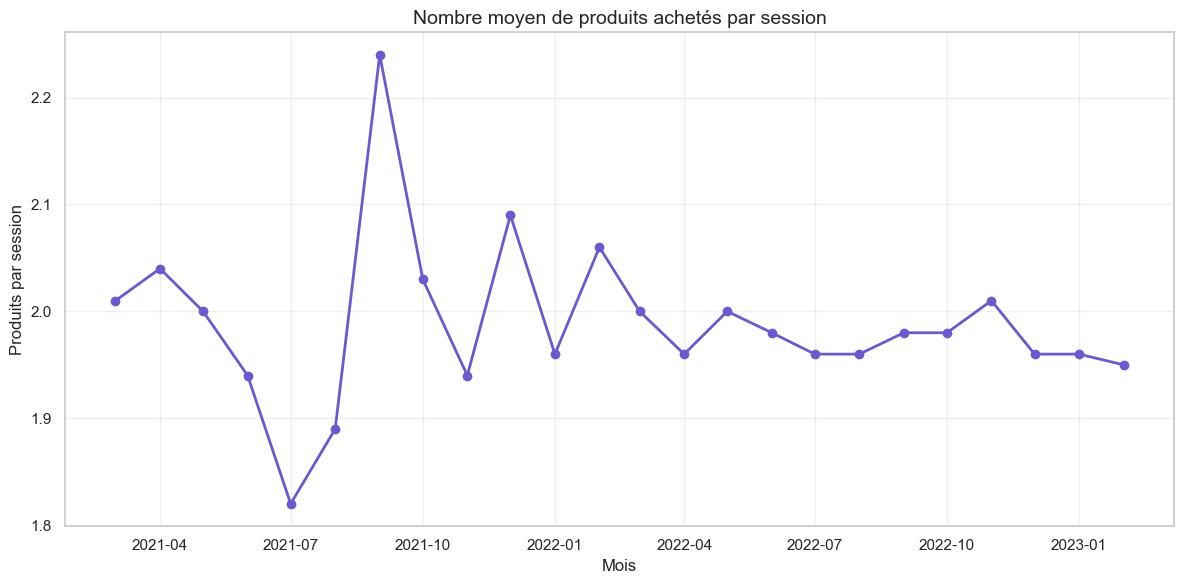

In [81]:
# Visualisation graphique 
plt.figure(figsize=(12, 6))
plt.plot(
    transactions_sessions_par_mois['mois'],
    transactions_sessions_par_mois['produits_par_session'],
    marker='o', color='slateblue', linewidth=2
)

plt.title("Nombre moyen de produits achetés par session", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Produits par session")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interprétation

Le nombre moyen de produits par session (prix moyen en volume) oscille autour de **1,9 à 2,1 produits par commande** sur l’ensemble de la période.

On note :
- un **creux en juillet 2021**, autour de **1,83 produit par session**, pouvant correspondre à une période de vacances ou à un repli temporaire,
- un **pic très net en septembre 2021** au-dessus de **2,25 produits par session**, qui coïncide avec une **hausse globale de l’activité** observée précédemment (CA, clients, transactions).

À partir de 2022, la moyenne se stabilise entre **1,9 et 2,0**, ce qui reflète une **habitude d’achat régulière**, avec peu de variation.

Ce ratio est un excellent indicateur du **comportement d’achat** :
- il peut être utilisé pour suivre l’impact d’actions commerciales (cross-selling, lots),
- ou servir de **base pour cibler une augmentation du prix moyen**.


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.12 - Analyse des références : tops, flops, répartition par catégorie</h3>
</div>


Dans cette section, nous analysons les performances individuelles des **références produits**.

Trois objectifs :
- identifier les **tops produits** (les plus vendus),
- détecter les **flops** (produits jamais ou très peu achetés),
- visualiser la **répartition des références vendues** par catégorie (`categ`).

Cette analyse permet :
- de mettre en avant les best-sellers,
- de repérer les produits à repositionner ou retirer,
- et d’évaluer l’équilibre de l’offre entre les catégories.


In [85]:
# Comptage des ventes par produit
top_produits = df_transactions_valides['id_prod'].value_counts().head(10).reset_index()
top_produits.columns = ['id_prod', 'nb_ventes']

display(top_produits)


,id_prod,nb_ventes
0,1_369,2340
1,1_417,2269
2,1_414,2246
3,1_498,2202
4,1_425,2163
5,1_403,2040
6,1_413,2036
7,1_412,2014
8,1_406,2003
9,1_407,2001


In [86]:
# Produits très peu vendus (vendus 1 ou 2 fois)
vente_par_produit = df_transactions_valides['id_prod'].value_counts()
flops = vente_par_produit[vente_par_produit <= 2].reset_index()
flops.columns = ['id_prod', 'nb_ventes']

print(f"Nombre de produits vendus au plus 2 fois : {flops.shape[0]}")
display(flops.head(10))


Nombre de produits vendus au plus 2 fois : 44


,id_prod,nb_ventes
0,0_1544,2
1,0_1120,2
2,0_88,2
3,0_1576,2
4,1_420,2
5,0_1871,2
6,0_1840,2
7,2_77,2
8,0_495,2
9,0_1803,2


### Produits très peu vendus

En complément des **21 produits jamais vendus** (identifiés précédemment),  
nous avons également repéré **les produits vendus une ou deux fois seulement**, qui peuvent être considérés comme des **flops commerciaux**.

Cela représente **{flops.shape[0]} références**, qui mériteraient :
- soit un repositionnement (titre, prix, mise en avant),
- soit un retrait de l’offre.

Un croisement avec les catégories ou la date d’entrée dans le catalogue peut affiner l’analyse.


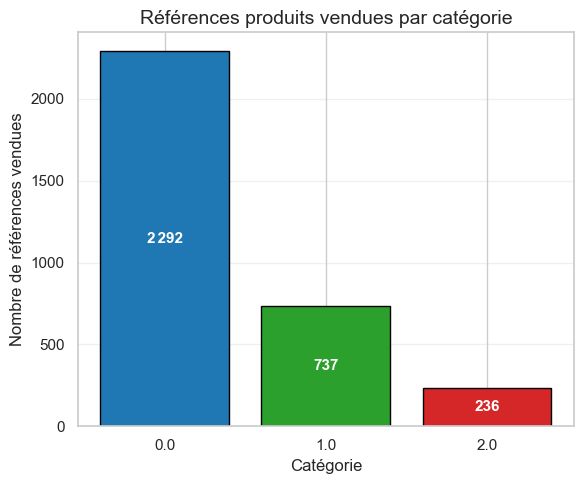

In [88]:
# Pour chaque produit vendu, on prend sa catégorie unique
refs_vendus = df_transactions_valides[['id_prod', 'categ']].drop_duplicates()

# Comptage des références distinctes vendues par catégorie
refs_par_categ = refs_vendus['categ'].value_counts().sort_index()

# Application des couleurs par catégorie
colors_barres = [couleurs_categories.get(categ, 'grey') for categ in refs_par_categ.index]

# Visualisation
plt.figure(figsize=(6, 5))
bars = plt.bar(
    refs_par_categ.index.astype(str),
    refs_par_categ.values,
    color=colors_barres,
    edgecolor='black'
)

# Ajout des valeurs en blanc dans les barres
for i, val in enumerate(refs_par_categ.values):
    plt.text(
        i,
        val / 2,
        f"{val:,}".replace(",", "\u202f"),
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

plt.title("Références produits vendues par catégorie", fontsize=14)
plt.xlabel("Catégorie")
plt.ylabel("Nombre de références vendues")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.13 - Répartition du chiffre d’affaires BtoB</h3>
</div>

### Répartition du chiffre d’affaires BtoB – analyse indirecte

La base `customers.csv` ne contient **aucun champ identifiant explicitement les clients professionnels** (BtoB)  
➤ Il n’est donc **pas possible de distinguer formellement BtoB / BtoC** à partir des variables disponibles.

---

### Approche alternative proNous avonstor, j’ai analysé les **clients ayant effectué le plus grand nombre d’achats sur la période**.  
L’idée : des clients dont le **volume de commandes est très élevé** pourraient **raisonnablement être considérés commeNous avons **.

J’ai ainsi extrait les **10 clients les plus actifs**, en nombre de trasactions :


In [91]:
# Détermination des clients qui ont effectué le plus de ventes (top clients)
top_clients = df_transactions_valides['client_id'].value_counts().head(10).reset_index()
top_clients.columns = ['client_id', 'nb_ventes']

display(top_clients)


,client_id,nb_ventes
0,c_1609,25586
1,c_6714,9199
2,c_3454,6793
3,c_4958,5222
4,c_2140,405
5,c_3263,403
6,c_2595,398
7,c_2077,386
8,c_1637,384
9,c_7421,381


### Interprétation

On constate que :
- Le **client c_1609** a réalisé **25 586 transactions** à lui seul,
- Les quatre premiers clients cumulent **46 800 transactions**, soit une part significative de l’activité.

Ces volumes sont **nettement supérieurs aux comportements d’achat attendus pour des particuliers**,  
ce qui permet de considérer qu’il s’agit **très probablement de clients professionnels (BtoB)**.

Cette approche reste **empirique**, mais elle offre un **indicateur utile en l’absence de variable dédiée**.


In [93]:
# Liste des 4 clients à forte activité
clients_b2b_potentiels = top_clients['client_id'].head(4).tolist()

# Filtrer df_transactions_valides sur ces clients
ca_b2b = df_transactions_valides[df_transactions_valides['client_id'].isin(clients_b2b_potentiels)]['price'].sum()

# Chiffre d'affaires total
ca_total = df_transactions_valides['price'].sum()

# Pourcentage
part_b2b = round((ca_b2b / ca_total) * 100, 2)

print(f"Chiffre d'affaires estimé BtoB : {ca_b2b:,.2f} €".replace(",", "\u202f"))
print(f"Part du CA total : {part_b2b:.2f} %")


Chiffre d'affaires estimé BtoB : 884 296.09 €
Part du CA total : 7.35 %


### Estimation du chiffre d’affaires BtoB

En considérant les 4 clients ayant réalisé plus de 5 000 transactions comme des **acheteurs professionnels**,  
nous estimons que :

- ils génèrent à eux seuls **884 296.09 €** de chiffre d’affaires,
- soit **7.35 %** du chiffre d’affaires total de la période.

Cette estimation renforce l’idée d’un **effet de concentration fort**, où quelques clients à usage intensif  
représentent une **part significative de l’activité** — typique du modèle BtoB.


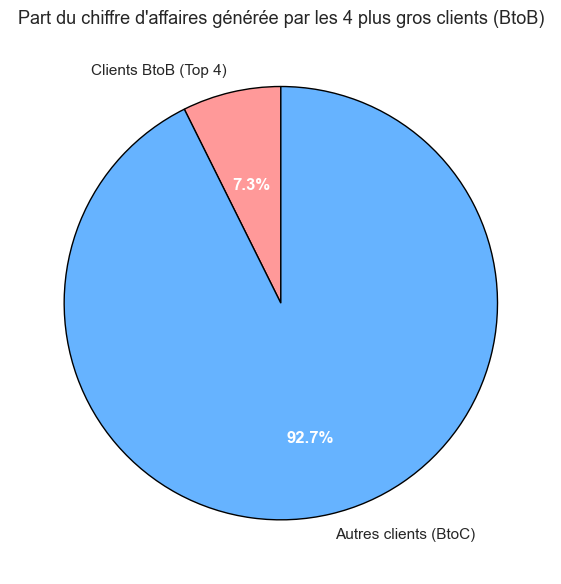

In [95]:
# Données pour le camembert
labels = ['Clients BtoB (Top 4)', 'Autres clients (BtoC)']
sizes = [part_b2b, 100 - part_b2b]
colors = ['#ff9999', '#66b3ff']

# Fonction personnalisée pour autopct (blanc + gras)
def make_autopct(values):
    def my_autopct(pct):
        return f"\n{pct:.1f}%" if pct > 0 else ''
    return my_autopct

# Affichage
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=make_autopct(sizes),
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

# Style du texte : blanc + gras
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title("Part du chiffre d'affaires générée par les 4 plus gros clients (BtoB)", fontsize=13)
plt.tight_layout()
plt.show()


Le graphique ci-dessus illustre la part du chiffre d’affaires réalisée par les **clients BtoB potentiels** (4 clients très intensifs).

Ils représentent à eux seuls près de **7,4 %** du chiffre d’affaires total.  
Cette concentration confirme la **forte dépendance économique à un nombre restreint de clients**, typique d’un modèle mixte ou partiellement BtoB.


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.14 - Courbe de Lorenz  : répartition du chiffre d'affaires entre les clients</h3>
</div>

La courbe de Lorenz est un outil graphique permettant de visualiser les **inégalités de répartition** d'une variable dans une population.  
Ici, nous l’utilisons pour analyser comment le **chiffre d'affaires** est réparti entre les **clients** de Lapage.

- Si tous les clients généraient le même montant de chiffre d'affaires, la courbe serait une **diagonale parfaite** (égalité).
- Plus la courbe s’éloigne de cette diagonale, plus la **répartition est inégalitaire** : une minorité de clients génère une majorité du CA.

Cette courbe précède le calcul de l’**indice de Gini**, qui quantifie cette inégalité.

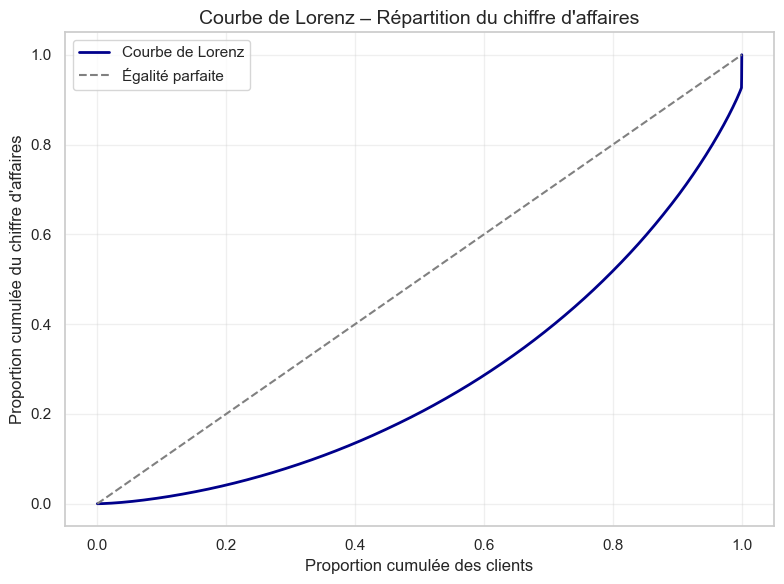

In [99]:
# Étape 1 – Calcul du chiffre d'affaires par client
ca_par_client = df_transactions_valides.groupby('client_id')['price'].sum().sort_values().reset_index()

# Étape 2 – Calcul des cumuls
ca_par_client['cum_clients'] = (np.arange(1, len(ca_par_client) + 1)) / len(ca_par_client)
ca_par_client['cum_ca'] = ca_par_client['price'].cumsum() / ca_par_client['price'].sum()

# Étape 3 – Tracé de la courbe
plt.figure(figsize=(8, 6))
plt.plot(ca_par_client['cum_clients'], ca_par_client['cum_ca'], label="Courbe de Lorenz", color='darkblue', linewidth=2)
plt.plot([0, 1], [0, 1], label="Égalité parfaite", linestyle='--', color='gray')

plt.title("Courbe de Lorenz – Répartition du chiffre d'affaires", fontsize=14)
plt.xlabel("Proportion cumulée des clients")
plt.ylabel("Proportion cumulée du chiffre d'affaires")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [100]:
#
ca_par_client

,client_id,price,cum_clients,cum_ca
0,c_8351,6.31,0.000116,5.246239e-07
1,c_8140,8.30,0.000233,1.214700e-06
2,c_8114,9.98,0.000349,2.044454e-06
3,c_4648,11.20,0.000465,2.975640e-06
4,c_4478,13.36,0.000581,4.086413e-06
...,...,...,...,...
8595,c_1570,5285.82,0.999535,9.264781e-01
8596,c_3454,114110.57,0.999651,9.359655e-01
8597,c_6714,153918.60,0.999767,9.487625e-01
8598,c_4958,290227.03,0.999884,9.728925e-01


### Interprétation

La courbe est nettement éloignée de la diagonale, ce qui montre une forte concentration du chiffre d'affaires :

- Une **petite proportion de clients** génère une **part très importante du CA**.
- Cette concentration est typique dans de nombreux secteurs : on parle souvent de **loi de Pareto** (20 % des clients génèrent 80 % du CA).

Cette visualisation renforce l’intérêt de segmenter et fidéliser les **clients à fort potentiel**, tout en réfléchissant à l’activation des clients peu contributeurs.

L’indice de Gini, que nous allons calculer ensuite, fournira une **mesure chiffrée** de cette inégalité.


### Indice de Gini

L’**indice de Gini** permet de mesurer l’inégalité de répartition du chiffre d’affaires entre les clients :

- Une valeur proche de **0** : tous les clients contribuent également au chiffre d'affaires.
- Une valeur proche de **1** : une poignée de clients concentre la quasi-totalité du chiffre d'affaires.


In [103]:
def gini(array):
    """Calcul de l’indice de Gini à partir d’un array numpy (non négatif)"""
    array = np.sort(array)                # tri des valeurs
    n = len(array)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * array)) / (n * np.sum(array)) - (n + 1) / n

# Application au chiffre d'affaires par client
gini_index = gini(ca_par_client['price'].values)

print(f"Indice de Gini du chiffre d’affaires client : {gini_index:.4f}")


Indice de Gini du chiffre d’affaires client : 0.4419


Ici, l’indice de Gini est de **0,4419**, ce qui révèle une inégalité modérée à forte :
une partie relativement restreinte des clients contribue à une grande part du chiffre d’affaires total.

Cette observation confirme la courbe de Lorenz : le chiffre d’affaires n’est pas réparti uniformément dans la base clients.

------------
Il est important de noter que 4 clients, présumés **B2B** en raison de leur très fort volume de transactions, génèrent à eux seuls **7,4 % du chiffre d’affaires total**.

Leur poids démesuré accentue artificiellement l’inégalité dans la distribution du chiffre d’affaires, ce que reflètent :

- la courbe de Lorenz, plus incurvée,

- et l’indice de Gini, plus élevé (0,4419 ici).

Une analyse complémentaire excluant ces **clients professionnels** permettrait de mieux comprendre le comportement des clients particuliers (B2C), qui représentent la majorité de la base.


In [105]:
# Liste des clients B2B présumés (pour rappel)
clients_b2b_potentiels = top_clients['client_id'].head(4).tolist()

# Création d’un DataFrame filtré pour ne garder que les clients B2C
df_b2c = df_transactions_valides[~df_transactions_valides['client_id'].isin(clients_b2b_potentiels)].copy()

# Vérification rapide
print(f"Nombre de transactions B2C : {df_b2c.shape[0]}")
print(f"Nombre de clients B2C uniques : {df_b2c['client_id'].nunique()}")


Nombre de transactions B2C : 640734
Nombre de clients B2C uniques : 8596


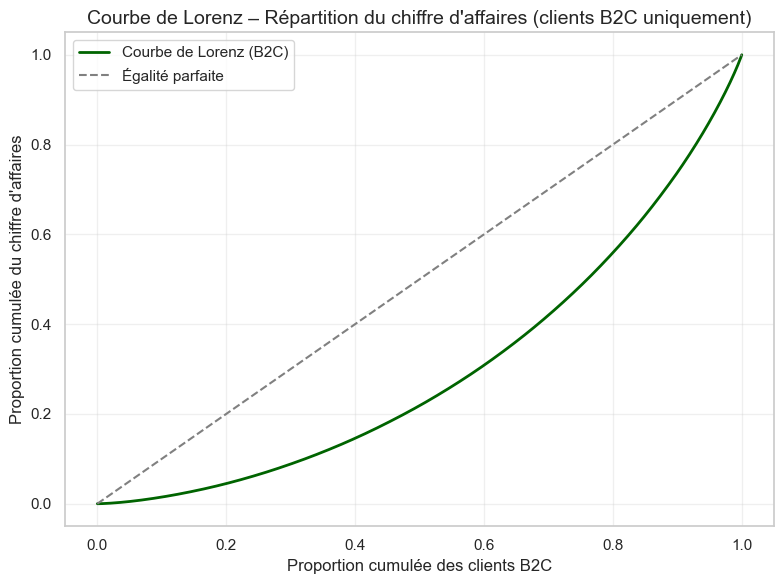

In [106]:
# Étape 1 – Calcul du chiffre d'affaires par client B2C
ca_par_client_b2c = df_b2c.groupby('client_id')['price'].sum().sort_values().reset_index()

# Étape 2 – Calcul des cumuls
ca_par_client_b2c['cum_clients'] = (np.arange(1, len(ca_par_client_b2c) + 1)) / len(ca_par_client_b2c)
ca_par_client_b2c['cum_ca'] = ca_par_client_b2c['price'].cumsum() / ca_par_client_b2c['price'].sum()

# Étape 3 – Tracé de la courbe de Lorenz B2C
plt.figure(figsize=(8, 6))
plt.plot(ca_par_client_b2c['cum_clients'], ca_par_client_b2c['cum_ca'],
         label="Courbe de Lorenz (B2C)", color='darkgreen', linewidth=2)
plt.plot([0, 1], [0, 1], label="Égalité parfaite", linestyle='--', color='gray')

plt.title("Courbe de Lorenz – Répartition du chiffre d'affaires (clients B2C uniquement)", fontsize=14)
plt.xlabel("Proportion cumulée des clients B2C")
plt.ylabel("Proportion cumulée du chiffre d'affaires")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [107]:
# Calcul de l’indice de Gini pour les clients B2C
gini_b2c = 1 - 2 * np.trapz(ca_par_client_b2c['cum_ca'], ca_par_client_b2c['cum_clients'])
print(f"Indice de Gini B2C : {gini_b2c:.4f}")


Indice de Gini B2C : 0.3983


### Interprétation – Concentration du chiffre d'affaires chez les clients B2C

La **courbe de Lorenz** ci-dessus montre que la répartition du chiffre d'affaires parmi les **clients particuliers (B2C)** reste inégalitaire, mais **moins fortement concentrée** qu'en incluant les clients professionnels.

L’**indice de Gini** obtenu est de **0,3983**, contre **0,4419** précédemment.  
Cela indique que les clients BtoB identifiés **accentuaient significativement la concentration du chiffre d’affaires**.

Même sans ces grands comptes, la distribution reste déséquilibrée : une minorité de clients B2C génère une part importante du CA total.


Pour le reste de l'analyse, nous nous concentrerons uniquement sur les clients B2C (en prenant en compte le dataframe df_b2c)

<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 2 - ANALYSE DES COMPORTEMENTS CLIENTS</h2>
</div>


<div style="background-color: RGB(109,183,197);">
  <h3 style="margin: auto; padding: 15px; color: white;">2.1 – Corrélation entre le genre et les catégories de livres achetés</h3>
</div>


Dans cette section, nous cherchons à savoir s'il existe une association entre le **genre** des clients et le **type de livres achetés**.

Les deux variables que nous allons comparer sont **qualitatives** :

- le **genre**, qui peut prendre les modalités : `Homme`, `Femme` ;
- la **catégorie de livres achetés**, représentée dans les données par les valeurs `0`, `1` ou `2`.

Ces codes correspondent probablement à une typologie interne de produits, mais nous ne disposons pas de leur signification précise. Cela ne pose pas de problème pour notre analyse, car nous nous concentrons uniquement sur la distribution entre modalités.

Étant donné que ces deux variables ont **plus de deux modalités**, et que nos effectifs sont suffisamment grands, le **test du Chi-2 d’indépendance** est le plus approprié ici. Ce test permettra de vérifier si la répartition des catégories de livres varie significativement selon le genre des clients.


In [113]:
# visualisation de la table de contingence entre le genre et les catégories de livres achetés
# 1. On garde uniquement les colonnes utiles depuis df_b2c
df_genre_categ = df_b2c[['client_id', 'sex', 'categ']].dropna()

# 2. Création de la table de contingence : nombre de transactions par sexe et catégorie
table_contingence = pd.crosstab(df_genre_categ['sex'], df_genre_categ['categ'])

# 3. Affichage
table_contingence


categ,0.0,1.0,2.0
sex,,,
f,200793,115721,16980
m,186488,104884,15868


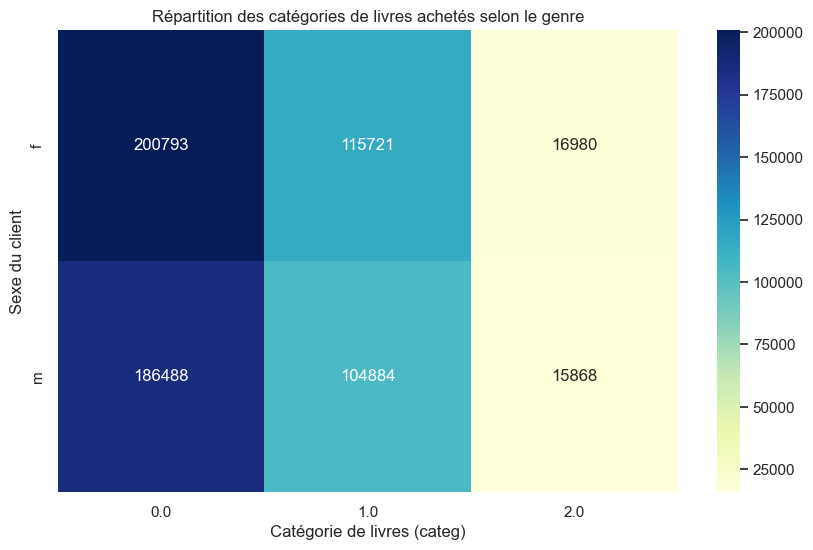

In [114]:
# visualisation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(table_contingence, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Répartition des catégories de livres achetés selon le genre")
plt.xlabel("Catégorie de livres (categ)")
plt.ylabel("Sexe du client")
plt.show()


In [115]:
# Calculer le test du Chi-2

# H0 : la catégorie de livres achetés est indépendante du genre des clients
# H1 : la catégorie de livres achetés dépend du genre des clients

from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(table_contingence)

print(f"Statistique Chi-2: {chi2_stat:.2f}")
print(f"Valeur p: {p_value:.8f}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)

if p_value < 0.05:
    print("Il existe une association significative entre le genre et la catégorie de livres achetés.")
else:
    print("Aucune association significative détectée entre le genre et la catégorie de livres achetés.")

Statistique Chi-2: 22.67
Valeur p: 0.00001196
Degrés de liberté: 2
Fréquences attendues:
[[201574.89662481 114822.13191434  17096.97146086]
 [185706.10337519 105782.86808566  15751.02853914]]
Il existe une association significative entre le genre et la catégorie de livres achetés.


Le test du Chi-2 d’indépendance appliqué à notre table de contingence permet d’évaluer s’il existe un lien entre le **genre du client** (`sex`) et la **catégorie de livres achetés** (`categ`).

- **Statistique de test** : 22.67  
- **Degrés de liberté** : 2  
- **Valeur p** : 0.00001196

La **statistique de test** (22,67) indique un écart net entre ce qu’on observe et ce qu’on attendrait si les deux variables étaient indépendantes.

La **valeur p étant largement inférieure à 0.05**, nous rejetons l’hypothèse nulle d’indépendance.  

Il existe donc **une association statistiquement significative** entre le genre et les catégories de livres achetées.

Même si les proportions par genre semblent proches, le volume de données très élevé rend cette différence **statistiquement significative**, bien que **l'effet soit probablement faible**.

Cela signifie que **le genre influence légèrement les choix de catégories de livres**, mais l’écart observé reste modéré en pratique.


<div style="background-color: RGB(109,183,197);">
  <h3 style="margin: auto; padding: 15px; color: white;">2.2 – Corrélation entre l'âge des clients et le montant total de leurs achats</h3>
</div>


Dans cette section, nous cherchons à savoir s’il existe une relation entre l’**âge** des clients et le **montant total de leurs achats**.

Les deux variables étudiées sont **quantitatives continues** :
- `age` : l’âge du client (en années)
- `price` : le montant d’un achat individuel, que nous allons sommer pour obtenir le total par client

L’objectif est de déterminer si les clients plus âgés dépensent plus ou moins que les plus jeunes.  
Pour cela, nous allons d’abord calculer le montant total dépensé par chaque client, puis vérifier la distribution des données afin de choisir le test de corrélation adapté.

Nous utiliserons :
- le **test de Pearson** si les données suivent une distribution normale,
- sinon, le **test de Spearman**, plus robuste aux asymétries.


In [119]:
# Calcul du montant total des achats par client

# Regrouper les données par client_id et sommer les prix
df_total_achats = df_b2c.groupby('client_id', as_index=False)['price'].sum()

# Renommer la colonne pour plus de clarté
df_total_achats.rename(columns={'price': 'montant_total_achats'}, inplace=True)

# Afficher les 5 premières lignes pour vérification
df_total_achats.head()


,client_id,montant_total_achats
0,c_1,629.02
1,c_10,1353.60
2,c_100,254.85
3,c_1000,2291.88
4,c_1001,1823.85


In [120]:
# Extraire l’âge de chaque client
df_age = df_b2c[['client_id', 'age']].drop_duplicates()

# Fusion avec le montant total des achats
df_age_achats = pd.merge(df_total_achats, df_age, on='client_id')

# Vérification rapide
df_age_achats.head()


,client_id,montant_total_achats,age
0,c_1,629.02,68.0
1,c_10,1353.60,67.0
2,c_100,254.85,31.0
3,c_1000,2291.88,57.0
4,c_1001,1823.85,41.0


Moyenne du montant total des achats : 1296.34 €
Écart-type : 958.40 €


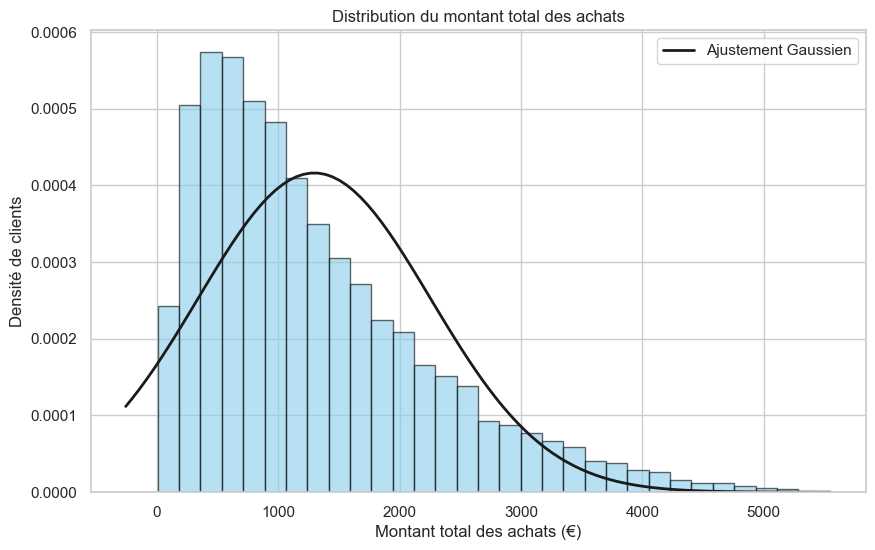

In [121]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Extraire la variable à analyser
montants = df_age_achats['montant_total_achats'].dropna()

# Calcul de la moyenne et de l'écart-type
mean_montant = montants.mean()
std_montant = montants.std()

print(f"Moyenne du montant total des achats : {mean_montant:.2f} €")
print(f"Écart-type : {std_montant:.2f} €")

# Tracé de l'histogramme avec courbe gaussienne
plt.figure(figsize=(10, 6))

# Histogramme avec densité
plt.hist(montants, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(montants)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Tracer la courbe de densité gaussienne
plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')

# Titres et légendes
plt.title('Distribution du montant total des achats')
plt.xlabel('Montant total des achats (€)')
plt.ylabel('Densité de clients')
plt.legend()

plt.show()


Le graphique ci-dessus montre la **distribution du montant total des achats** effectués par les clients.

L’histogramme représente la **densité de clients** par tranches de montant (par exemple : 0–500 €, 500–1000 €, etc.), tandis que la courbe noire correspond à une **courbe de Gauss théorique** ajustée aux données (courbe de densité normale).

**Statistiques descriptives** :
- Moyenne du montant total des achats : **1296,34 €**
- Écart-type : **958,40 €**

On observe une distribution :
- **asymétrique** (la queue de distribution est étirée vers la droite),
- avec une **majorité de clients ayant dépensé entre 500 € et 1500 €**,
- et une minorité ayant dépensé des montants nettement plus élevés (jusqu’à plus de 5000 €).

Cette distribution n’est **pas gaussienne** (non symétrique), ce qui **exclut l’utilisation du test de Pearson**.  
Nous utiliserons donc un test **non paramétrique** plus adapté à ce type de données : le **test de Spearman**.


In [123]:
from scipy.stats import spearmanr

# Test de Spearman entre l'âge des clients et le montant total des achats
spearman_coef, spearman_p = spearmanr(df_age_achats['age'], df_age_achats['montant_total_achats'])

# Affichage des résultats
print(f"Coefficient de Spearman : {spearman_coef:.4f}")
print(f"Valeur p : {spearman_p:.12f}")

if spearman_p < 0.05:
    print("Corrélation significative entre l'âge et le montant total des achats (test de Spearman).")
else:
    print("Aucune corrélation significative détectée entre l'âge et le montant total des achats.")


Coefficient de Spearman : -0.1845
Valeur p : 0.000000000000
Corrélation significative entre l'âge et le montant total des achats (test de Spearman).


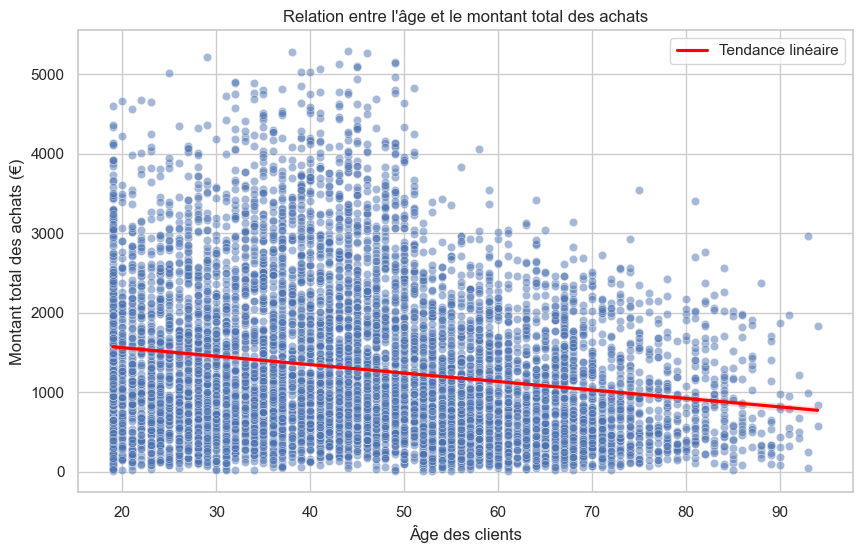

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Nuage de points (scatterplot)
sns.scatterplot(data=df_age_achats, x='age', y='montant_total_achats', alpha=0.5)

# Ligne de tendance linéaire avec label explicite
sns.regplot(
    data=df_age_achats,
    x='age',
    y='montant_total_achats',
    scatter=False,
    color='red',
    label='Tendance linéaire'
)

# Titre, axes et légende
plt.title("Relation entre l'âge et le montant total des achats")
plt.xlabel("Âge des clients")
plt.ylabel("Montant total des achats (€)")
plt.legend()

plt.show()


Le graphique ci-dessus explore la relation entre l’**âge des clients** et le **montant total de leurs achats**.

Le **coefficient de corrélation de Spearman est de –0.1845**, indiquant une **faible corrélation négative** entre l’âge et le montant total dépensé. Cela signifie que, de manière générale, **les clients plus âgés ont tendance à dépenser un peu moins** que les plus jeunes.

Cette corrélation est **statistiquement significative** (valeur p < 0.000001), donc elle n’est **pas due au hasard**, même si l’intensité de la relation reste faible.

Le **nuage de points** montre une grande variabilité individuelle, mais la **ligne de tendance rouge** confirme une légère baisse des montants dépensés avec l’âge.  


<div style="background-color: RGB(109,183,197);">
  <h3 style="margin: auto; padding: 15px; color: white;">2.2 – Corrélation entre l'âge et la fréquence d’achat</h3>
</div>


Dans cette section, nous cherchons à déterminer s’il existe une relation entre l’**âge des clients** et la **fréquence de leurs achats**.

Les deux variables étudiées sont **quantitatives** :
- `age` : âge du client, exprimé en années (quantitative continue)
- `frequence_achat` : nombre total de transactions par client (quantitative discrète)

L’objectif est de voir si les clients plus âgés achètent plus ou moins fréquemment que les plus jeunes.

Nous allons :
1. Calculer la fréquence d’achat par client à partir des données de `df_b2c` ;
2. Vérifier visuellement la distribution de cette variable ;
3. Appliquer un test de corrélation ; nous utiliserons :
   - le **test de Pearson** si les données suivent une distribution normale,
   - sinon, le **test de Spearman**, plus robuste aux asymétries ;
4. Visualiser la relation via un nuage de points et une ligne de tendance.


In [128]:
# Calcul de la fréquence d’achat par client

# Calculer le nombre de transactions par client
df_freq = df_b2c.groupby('client_id', as_index=False).agg(frequence_achat=('session_id', 'count'))

# Fusion avec l'âge
df_age_freq = df_b2c[['client_id', 'age']].drop_duplicates().merge(df_freq, on='client_id')

# Aperçu
df_age_freq.head()


,client_id,age,frequence_achat
0,c_1,68.0,43
1,c_10,67.0,58
2,c_100,31.0,8
3,c_1000,57.0,126
4,c_1001,41.0,103


Moyenne de la fréquence d’achat : 74.54
Écart-type : 68.07


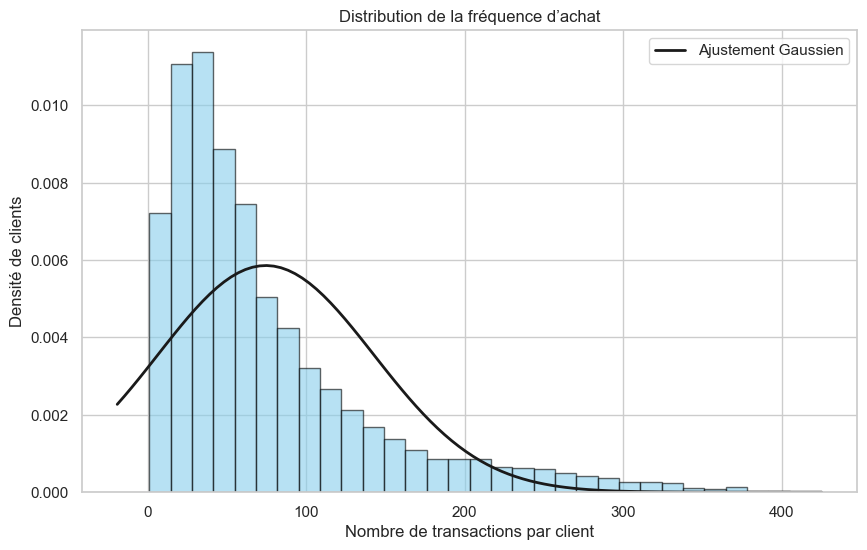

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# On récupère la variable à analyser
frequences = df_age_freq['frequence_achat'].dropna()

# Calcul des statistiques descriptives
mean_freq = frequences.mean()
std_freq = frequences.std()

print(f"Moyenne de la fréquence d’achat : {mean_freq:.2f}")
print(f"Écart-type : {std_freq:.2f}")

# Tracé de l'histogramme + courbe de Gauss
plt.figure(figsize=(10, 6))

# Histogramme avec densité
plt.hist(frequences, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(frequences)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Courbe gaussienne
plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')

# Titres et légendes
plt.title("Distribution de la fréquence d’achat")
plt.xlabel("Nombre de transactions par client")
plt.ylabel("Densité de clients")
plt.legend()

plt.show()


Le graphique ci-dessus représente la **distribution de la fréquence d’achat** par client.

**Statistiques descriptives** :
- Moyenne : **74,54 transactions**
- Écart-type : **68,07**

L’histogramme montre une **distribution fortement asymétrique** : la majorité des clients effectuent moins de 100 transactions, tandis qu’une minorité réalise plusieurs centaines d’achats.

Visuellement, cette distribution **ne semble pas suivre une courbe gaussienne** (courbe noire), car elle est étalée vers la droite.

Pour confirmer cette observation, nous allons maintenant réaliser un **test de normalité** (test de Shapiro-Wilk) sur la variable `frequence_achat`.


In [131]:
# test de la normalité (test de Shapiro-Wilk)
# H₀ (hypothèse nulle) : les données suivent une loi normale
# H₁ (hypothèse alternative) : les données ne suivent pas une loi normale

from scipy.stats import shapiro

# Test de normalité (limité à 5000 observations)
echantillon = frequences.sample(5000, random_state=42) if len(frequences) > 5000 else frequences

stat, p = shapiro(echantillon)

print(f"Statistique de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p:.6f}")

if p < 0.05:
    print("p est < à 0,05 ; on rejette H₀, la distribution n'est pas normale → on utilisera le test de Spearman.")
else:
    print("p est ≥ à 0,05 ; on ne rejette pas H₀, la distribution est compatible avec une loi normale → on peut utiliser le test de Pearson.")


Statistique de Shapiro-Wilk : 0.8167
Valeur p : 0.000000
p est < à 0,05 ; on rejette H₀, la distribution n'est pas normale → on utilisera le test de Spearman.


Le test de **Shapiro-Wilk** permet de vérifier si une variable suit une distribution normale.

Dans notre cas :
- Statistique : **0.8167**
- Valeur p : **≈ 0.000000**

La valeur p étant très inférieure au seuil de 0,05, nous **rejetons l’hypothèse de normalité**.  
Cela signifie que la variable `frequence_achat` **ne suit pas une loi normale**, ce qui confirme ce que nous avions observé visuellement.

Par conséquent, nous utiliserons un **test de corrélation non paramétrique** : **le test de Spearman**, plus adapté aux distributions asymétriques.


In [133]:
from scipy.stats import spearmanr

# Test de corrélation entre l’âge et la fréquence d’achat
# H0 : il n’y a pas de lien monotone entre l’âge et la fréquence d’achat
# H1 : il existe un lien monotone

coef_spearman, p_spearman = spearmanr(df_age_freq['age'], df_age_freq['frequence_achat'])

print(f"Coefficient de Spearman (ρ) : {coef_spearman:.4f}")
print(f"Valeur p : {p_spearman:.6f}")

if p_spearman < 0.05:
    print("Corrélation significative entre l'âge et la fréquence d'achat.")
else:
    print("Aucune corrélation significative détectée entre l'âge et la fréquence d'achat.")


Coefficient de Spearman (ρ) : 0.1277
Valeur p : 0.000000
Corrélation significative entre l'âge et la fréquence d'achat.


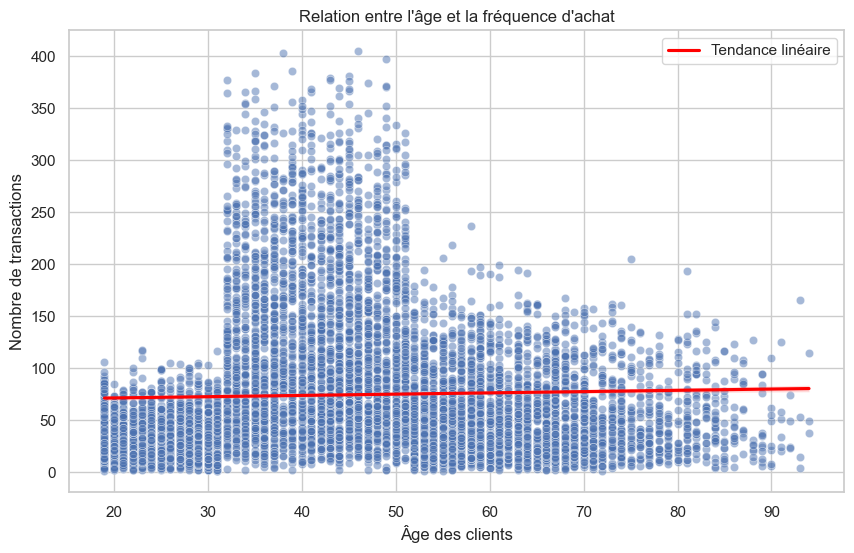

In [134]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_age_freq, x='age', y='frequence_achat', alpha=0.5)
sns.regplot(
    data=df_age_freq,
    x='age',
    y='frequence_achat',
    scatter=False,
    color='red',
    label='Tendance linéaire'
)
plt.title("Relation entre l'âge et la fréquence d'achat")
plt.xlabel("Âge des clients")
plt.ylabel("Nombre de transactions")
plt.legend()
plt.show()


Le **test de corrélation de Spearman** mesure s’il existe une relation monotone entre l’âge des clients et la fréquence de leurs achats.

**Résultats obtenus** :
- Coefficient de Spearman (ρ) : **0.1277**
- Valeur p : **< 0.000001**

La valeur p étant largement inférieure à 0,05, la corrélation est **statistiquement significative**.  
Cela signifie qu’il existe une **relation réelle, mais faible**, entre les deux variables.

Le coefficient positif indique une **tendance légèrement croissante** : les clients plus âgés ont, en moyenne, une fréquence d’achat un peu plus élevée.  
Cependant, cette relation reste **faible** et doit être interprétée avec prudence sur le plan opérationnel.

Le **nuage de points** confirme cette tendance : bien que la dispersion soit importante, la **ligne de régression rouge** montre une pente positive modérée.

limite : nuage de points, entre 30 et 50 ans beaucoup d'achats

<div style="background-color: RGB(109,183,197);">
  <h3 style="margin: auto; padding: 15px; color: white;">2.4 – Corrélation entre l'âge et le panier moyen</h3>
</div>


Dans cette section, nous cherchons à savoir s’il existe une relation entre l’**âge des clients** et leur **panier moyen**.

Les deux variables étudiées sont **quantitatives** :
- `age` : âge du client, en années (quantitative continue)
- `panier_moyen` : montant moyen dépensé par transaction pour chaque client

Le **panier moyen** sera calculé comme le rapport entre :
- le **montant total des achats** par client,
- et le **nombre total de transactions**.

Nous allons :
1. Calculer le panier moyen par client à partir de `df_b2c` ;
2. Visualiser la distribution de cette variable (histogramme + ajustement gaussien) ;
3. Tester la normalité via le test de Shapiro-Wilk ;
4. Appliquer un test de corrélation (Pearson ou Spearman) ;
5. Visualiser la relation par un nuage de points et une tendance linéaire.


In [138]:
# 1. Total des achats par client
df_total = df_b2c.groupby('client_id', as_index=False)['price'].sum()
df_total.rename(columns={'price': 'montant_total_achats'}, inplace=True)

# 2. Nombre de transactions par client
df_freq = df_b2c.groupby('client_id', as_index=False)['session_id'].count()
df_freq.rename(columns={'session_id': 'frequence_achat'}, inplace=True)

# 3. Fusion des deux
df_panier = df_total.merge(df_freq, on='client_id')

# 4. Calcul du panier moyen
df_panier['panier_moyen'] = df_panier['montant_total_achats'] / df_panier['frequence_achat']

# 5. Ajout de l’âge depuis df_b2c
df_age = df_b2c[['client_id', 'age']].drop_duplicates()
df_age_panier = df_panier.merge(df_age, on='client_id')

# Vérification
df_age_panier.head()


,client_id,montant_total_achats,frequence_achat,panier_moyen,age
0,c_1,629.02,43,14.628372,68.0
1,c_10,1353.60,58,23.337931,67.0
2,c_100,254.85,8,31.856250,31.0
3,c_1000,2291.88,126,18.189524,57.0
4,c_1001,1823.85,103,17.707282,41.0


Nous avons calculé le **panier moyen** par client, défini comme le **montant total des achats divisé par le nombre de transactions**.

Pour cela, nous avons :
- agrégé les achats (`price`) pour obtenir le total dépensé par client,
- compté le nombre de transactions (`session_id`) par client,
- puis calculé le **panier moyen**.

Nous avons ensuite associé chaque client à son **âge** (`age`) pour préparer l’analyse de la corrélation.

Nous allons maintenant observer la **distribution du panier moyen** afin de déterminer s’il suit une loi normale.
Cela nous permettra de choisir le test de corrélation le plus approprié.


Moyenne du panier moyen : 21.93 €
Écart-type : 14.63 €


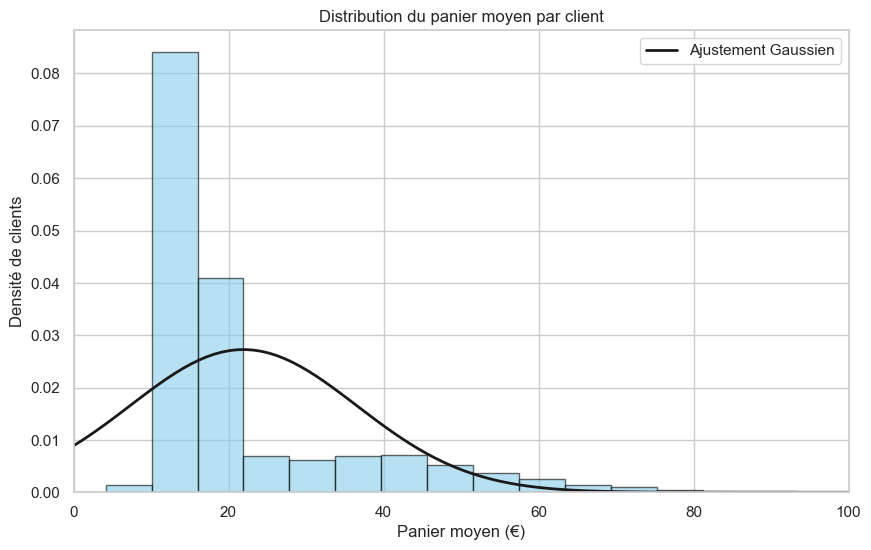

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Récupérer la variable à analyser
paniers = df_age_panier['panier_moyen'].dropna()

# Statistiques descriptives
mean_panier = paniers.mean()
std_panier = paniers.std()

print(f"Moyenne du panier moyen : {mean_panier:.2f} €")
print(f"Écart-type : {std_panier:.2f} €")

# Tracé de l'histogramme + courbe de Gauss (avec axe limité à 100 €)
plt.figure(figsize=(10, 6))

# Histogramme avec densité
plt.hist(paniers, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(paniers)
x = np.linspace(0, 100, 100)
p = norm.pdf(x, mu, std)

# Courbe de Gauss
plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')

# Titres, étiquettes et limites
plt.title("Distribution du panier moyen par client")
plt.xlabel("Panier moyen (€)")
plt.ylabel("Densité de clients")
plt.xlim(0, 100)
plt.legend()

plt.show()


Le graphique ci-dessus montre la **distribution du panier moyen par client**, c’est-à-dire le montant moyen dépensé à chaque transaction.

**Statistiques descriptives** :
- Moyenne du panier moyen : **21,93 €**
- Écart-type : **14,63 €**

La distribution est clairement **asymétrique**, avec une forte concentration de clients dont le panier moyen se situe entre 10 € et 30 €, et une **longue traîne** vers les paniers plus élevés.

Visuellement, la courbe de Gauss (en noir) ne correspond pas bien à la forme réelle de la distribution :  
la courbe est **décalée, non symétrique**, et le pic est beaucoup plus marqué à gauche.

Pour confirmer cela de manière statistique, nous allons maintenant réaliser un **test de normalité (test de Shapiro-Wilk)** sur la variable `panier_moyen`.  
Cela nous permettra de savoir si nous pouvons utiliser un test de corrélation paramétrique (Pearson), ou s’il faut nous orienter vers un test non paramétrique (Spearman).


In [142]:
# test de la normalité (test de Shapiro-Wilk)
# H₀ (hypothèse nulle) : les données suivent une loi normale
# H₁ (hypothèse alternative) : les données ne suivent pas une loi normale

from scipy.stats import shapiro

# Echantillonner si la taille dépasse 5000 observations (limite du test Shapiro)
echantillon = paniers.sample(5000, random_state=42) if len(paniers) > 5000 else paniers

# Test de normalité de Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(echantillon)

print(f"Statistique de Shapiro-Wilk : {stat_shapiro:.4f}")
print(f"Valeur p : {p_shapiro:.6f}")

# Interprétation de base en sortie console
if p_shapiro < 0.05:
    print("p est < à 0,05 ; on rejette H₀, la distribution du panier moyen n'est pas normale → on utilisera le test de Spearman.")
else:
    print("p est ≥ à 0,05 ; on ne rejette pas H₀, la distribution du panier moyen est compatible avec une loi normale → on peut utiliser le test de Pearson.")


Statistique de Shapiro-Wilk : 0.6828
Valeur p : 0.000000
p est < à 0,05 ; on rejette H₀, la distribution du panier moyen n'est pas normale → on utilisera le test de Spearman.


Le **test de Shapiro-Wilk** permet de vérifier si une variable suit une **distribution normale**.

**Résultats du test sur la variable `panier_moyen`** :
- Statistique de Shapiro-Wilk : **0.6828**
- Valeur p : **< 0.000001**

La valeur p est largement inférieure à 0,05 : nous **rejetons l’hypothèse nulle de normalité**.

De plus, la **statistique de 0.6828** est très éloignée de 1, ce qui indique que la **forme de la distribution diffère fortement** d’une courbe de Gauss.

Cela confirme ce que nous avions observé visuellement : la distribution du panier moyen est **fortement asymétrique**, donc **non gaussienne**.

Nous utiliserons donc le **test de Spearman**, plus adapté aux distributions non normales, pour étudier la corrélation entre **l’âge** et le **panier moyen**.


In [144]:
from scipy.stats import spearmanr

# Test de Spearman : corrélation âge vs panier moyen
coef_spearman, p_spearman = spearmanr(df_age_panier['age'], df_age_panier['panier_moyen'])

print(f"Coefficient de Spearman (ρ) : {coef_spearman:.4f}")
print(f"Valeur p : {p_spearman:.6f}")

if p_spearman < 0.05:
    print("Corrélation significative entre l'âge et le panier moyen.")
else:
    print("Aucune corrélation significative détectée entre l'âge et le panier moyen.")


Coefficient de Spearman (ρ) : -0.3259
Valeur p : 0.000000
Corrélation significative entre l'âge et le panier moyen.


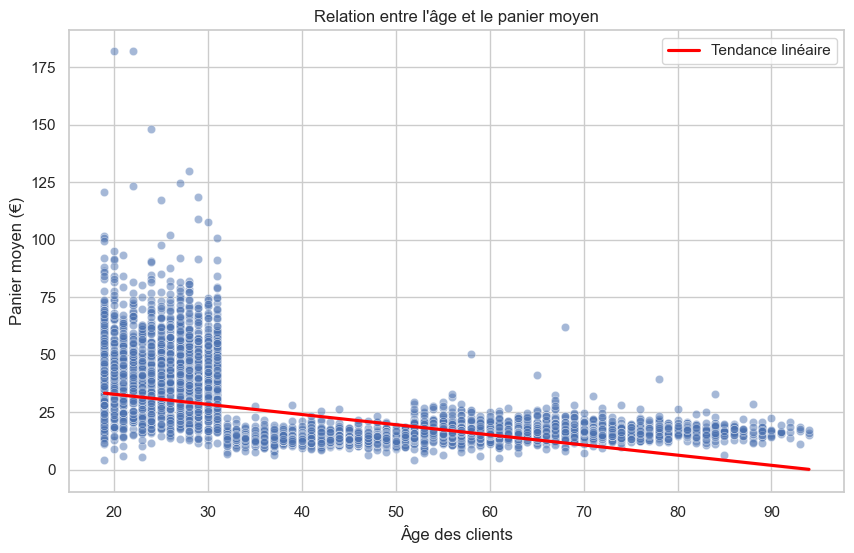

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_age_panier, x='age', y='panier_moyen', alpha=0.5)

sns.regplot(
    data=df_age_panier,
    x='age',
    y='panier_moyen',
    scatter=False,
    color='red',
    label='Tendance linéaire'
)

plt.title("Relation entre l'âge et le panier moyen")
plt.xlabel("Âge des clients")
plt.ylabel("Panier moyen (€)")
plt.legend()
plt.show()


Le **test de corrélation de Spearman** permet d’évaluer s’il existe une relation monotone entre l’**âge des clients** et leur **panier moyen** (montant moyen dépensé par transaction).

**Résultats du test** :
- Coefficient de Spearman (ρ) : **–0.3259**
- Valeur p : **< 0.000001**

La valeur p étant largement inférieure à 0,05, nous pouvons conclure que cette **corrélation est statistiquement significative**.

Le coefficient de –0.3259 indique une **corrélation négative modérée** :  
**plus les clients sont âgés, plus leur panier moyen a tendance à être faible**.

Cela se confirme visuellement sur le **nuage de points** : la **ligne rouge de tendance décroissante** montre une baisse du panier moyen avec l’âge, malgré une forte dispersion individuelle.

Ce résultat suggère une **tendance comportementale structurelle** :  
les clients plus jeunes dépensent davantage par transaction que les clients plus âgés.


<div style="background-color: RGB(109,183,197);">
  <h3 style="margin: auto; padding: 15px; color: white;">2.5 – Corrélation entre l'âge et la catégorie de livres achetés</h3>
</div>


Dans cette dernière section, nous cherchons à savoir s’il existe une relation entre l’**âge des clients** (variable **quantitative**) et la **catégorie de livres qu’ils achètent** (variable **qualitative**).

La variable `categ` prend les valeurs **0**, **1** ou **2** : ce sont ses **modalités** (les différentes catégories de livres).

Nous allons déterminer si les **moyennes d’âge varient significativement selon la catégorie dominante achetée**.

Voici la démarche suivie :
1. Identifier pour chaque client sa **catégorie dominante**, c’est-à-dire celle qu’il a achetée le plus fréquemment ;
2. Comparer les **moyennes d’âge entre les groupes** définis par cette catégorie dominante ;
3. Vérifier les hypothèses de normalité (via le test de Shapiro-Wilk) et d’homogénéité des variances ;
4. La variable `categ` étant qualitative avec **3 modalités**, nous appliquerons :
   - un **test ANOVA** si les conditions sont remplies,
   - sinon, un **test de Kruskal-Wallis**, alternative non paramétrique à l’ANOVA.
5. Visualiser et interpréter les résultats.


In [149]:
# 1. Compter le nombre d'achats par client et par catégorie
df_categ_counts = df_b2c.groupby(['client_id', 'categ'], as_index=False).size()
df_categ_counts.rename(columns={'size': 'nb_achats'}, inplace=True)

# 2. Identifier la catégorie dominante (celle avec le plus de transactions)
df_categ_dominante = df_categ_counts.sort_values('nb_achats', ascending=False).drop_duplicates('client_id')

# 3. Renommer la colonne pour clarté
df_categ_dominante.rename(columns={'categ': 'categorie_dominante'}, inplace=True)

# 4. Ajouter l'âge des clients
df_age = df_b2c[['client_id', 'age']].drop_duplicates()
df_age_categ = df_categ_dominante.merge(df_age, on='client_id')

# Vérification
df_age_categ.head()


,client_id,categorie_dominante,nb_achats,age
0,c_1637,0.0,316,35.0
1,c_3263,0.0,314,38.0
2,c_5953,0.0,311,37.0
3,c_2140,0.0,310,46.0
4,c_2595,0.0,307,49.0


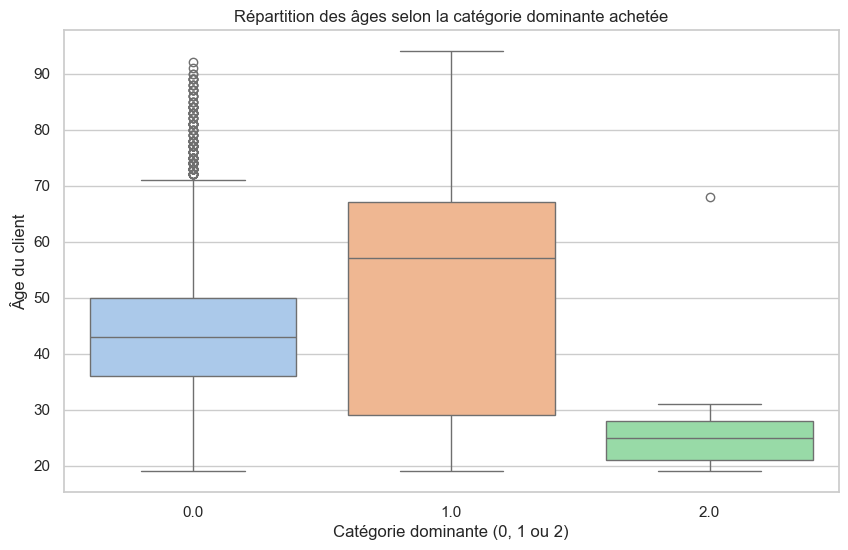

In [150]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_age_categ,
    x='categorie_dominante',
    y='age',
    hue='categorie_dominante',  # identique à x
    palette='pastel',
    dodge=False,
    legend=False
)
plt.title("Répartition des âges selon la catégorie dominante achetée")
plt.xlabel("Catégorie dominante (0, 1 ou 2)")
plt.ylabel("Âge du client")
plt.show()


Le graphique ci-dessus représente la répartition des âges des clients selon leur catégorie de livres dominante (valeurs possibles : 0, 1 ou 2).

On observe visuellement des différences marquées entre les groupes :

- Les clients achetant majoritairement des livres de catégorie 1 semblent en moyenne plus âgés.
- Ceux préférant la catégorie 2 sont globalement plus jeunes.
- Le groupe de la catégorie 0 est plus concentré autour de 40–50 ans.

Les médianes sont différentes, et la variabilité (écart interquartile) varie aussi d’un groupe à l’autre.

Ces éléments visuels laissent penser qu’il pourrait exister une différence significative des âges moyens selon la catégorie dominante.

Avant de choisir un test statistique adapté, nous devons vérifier si la variable `age` suit une **distribution normale dans chaque groupe**.

Nous allons donc appliquer un **test de Shapiro-Wilk**, qui permet d’évaluer la normalité de la distribution dans chaque modalité de la variable `categorie_dominante`.  
Cela nous orientera ensuite vers un **test ANOVA** (si la normalité est confirmée) ou vers un **test de Kruskal-Wallis** dans le cas contraire.


In [152]:
from scipy.stats import shapiro

# Initialiser un dictionnaire pour stocker les résultats
resultats_shapiro = {}

# Boucle sur chaque modalité de catégorie
for cat in sorted(df_age_categ['categorie_dominante'].unique()):
    ages_groupe = df_age_categ[df_age_categ['categorie_dominante'] == cat]['age'].dropna()
    
    # Echantillonner si plus de 5000 lignes (limite du test Shapiro)
    if len(ages_groupe) > 5000:
        ages_groupe = ages_groupe.sample(5000, random_state=42)
    
    stat, p_value = shapiro(ages_groupe)
    
    resultats_shapiro[cat] = {
        'statistique': round(stat, 4),
        'p_value': round(p_value, 6),
        'normalite': 'Non normale' if p_value < 0.05 else 'Normale'
    }

# Affichage des résultats
for cat, res in resultats_shapiro.items():
    print(f"Catégorie {cat} :")
    print(f"  Statistique de Shapiro-Wilk : {res['statistique']}")
    print(f"  Valeur p : {res['p_value']}")
    print(f"  → {res['normalite']}\n")


Catégorie 0.0 :
  Statistique de Shapiro-Wilk : 0.9533
  Valeur p : 0.0
  → Non normale

Catégorie 1.0 :
  Statistique de Shapiro-Wilk : 0.9112
  Valeur p : 0.0
  → Non normale

Catégorie 2.0 :
  Statistique de Shapiro-Wilk : 0.8774
  Valeur p : 0.0
  → Non normale



Afin de vérifier si l’on peut utiliser un **test ANOVA**, nous avons appliqué un **test de Shapiro-Wilk** dans chaque groupe de `categorie_dominante`, pour tester la normalité de la variable `age`.

**Résultats obtenus** :

- **Catégorie 0** :
  - Statistique de Shapiro-Wilk : **0.9533**
  - Valeur p : **< 0.000001** → Non normale

- **Catégorie 1** :
  - Statistique de Shapiro-Wilk : **0.9112**
  - Valeur p : **< 0.000001** → Non normale

- **Catégorie 2** :
  - Statistique de Shapiro-Wilk : **0.8774**
  - Valeur p : **< 0.000001** → Non normale

La **statistique de Shapiro-Wilk** donne une indication de la proximité à une distribution normale (plus elle est proche de 1, plus la forme de la distribution s’en rapproche).

Mais c’est la **valeur p** du test qui détermine si l’on peut considérer que la distribution suit une loi normale.

Ici, bien que les statistiques soient relativement proches de 1, les **valeurs p sont toutes très largement inférieures à 0,05**, ce qui signifie que l’écart à la normalité est **statistiquement significatif**.

En conséquence, nous **rejetons l’hypothèse de normalité** dans chacun des groupes.

Nous ne pouvons donc pas utiliser un test ANOVA, qui repose sur cette hypothèse.  
Nous appliquerons à la place le **test de Kruskal-Wallis**, qui permet de comparer les distributions d’une variable quantitative entre plusieurs groupes **sans supposer la normalité des données**.


In [154]:
from scipy.stats import kruskal

# Extraire les âges par groupe
ages_cat_0 = df_age_categ[df_age_categ['categorie_dominante'] == 0]['age']
ages_cat_1 = df_age_categ[df_age_categ['categorie_dominante'] == 1]['age']
ages_cat_2 = df_age_categ[df_age_categ['categorie_dominante'] == 2]['age']

# Appliquer le test de Kruskal-Wallis
stat_kruskal, p_kruskal = kruskal(ages_cat_0, ages_cat_1, ages_cat_2)

# Affichage des résultats
print(f"Statistique de Kruskal-Wallis : {stat_kruskal:.4f}")
print(f"Valeur p : {p_kruskal:.6f}")

if p_kruskal < 0.05:
    print("Il existe une différence significative d'âge entre au moins deux groupes.")
else:
    print("Aucune différence significative détectée entre les groupes.")


Statistique de Kruskal-Wallis : 2134.8539
Valeur p : 0.000000
Il existe une différence significative d'âge entre au moins deux groupes.


Nous avons appliqué un **test de Kruskal-Wallis** pour évaluer si la variable `age` diffère selon la **catégorie de livres dominante** achetée par les clients.

**Résultats du test** :
- Statistique de Kruskal-Wallis : **2134,85**
- Valeur p : **< 0.000001**

La valeur p étant très largement inférieure à 0,05, nous rejetons l’hypothèse nulle d’égalité entre les groupes.  
Il existe donc une **différence significative d’âge** entre **au moins deux des trois catégories**.

Autrement dit, l’âge des clients **varie en fonction de la catégorie de livres qu’ils achètent le plus fréquemment**.  
Ce résultat confirme visuellement ce que nous avions observé dans le boxplot : les profils d’âge sont distincts selon la catégorie dominante.